<div style="display: flex; background-color: RGB(111,46,54);" >
<h1 style="margin: auto; padding: 30px; color:#fff;">ANALYSE DES VENTES D'UNE LIBRAIRIE</h1>
</div>

<div style="background-color: RGB(160,111,119);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

#Importation de la librairie numpy 
import numpy as np

#Importation de la librairie plotly express
#import plotly.express as px

#Importation de la librairie plotly
import matplotlib.pyplot as plt

#Importation de la librairie Seaborn
import seaborn as sns

#Importation de la librairie ticker
import matplotlib.ticker as ticker

#Importation de la librairie datetime
import datetime

#Importation de la librairie mpatches
import matplotlib.patches as mpatches

#Importation de la librairie graph
import plotly.graph_objects as go

#Importation de la librairie statistics
import statistics

#Importation de la librairie norm
from scipy.stats import norm

#Importation de la librairie chi2_contingency
from scipy.stats import chi2_contingency

#Importation de la librairie shapiro
from scipy.stats import shapiro

#Importation de la librairie spearmanr
from scipy.stats import spearmanr

#Importation de la librairie stats
from scipy import stats

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">1.2 - Chargements des fichiers</h3>
</div>

In [2]:
#Importation du fichier customer.csv
df_customers = pd.read_csv("../DAN-P6-donnees/customers.csv")
#Importation du fichier products.csv
df_products = pd.read_csv("../DAN-P6-donnees/products.csv")
#Importation du fichier Transactions.csv
df_transactions = pd.read_csv("../DAN-P6-donnees/transactions.csv")

<div style="background-color: RGB(160,111,119);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">2.1 - Analyse exploratoire du fichier customer.csv</h3>
</div>

In [3]:
#Dimension du dataset customer
print("Le dataframe customer comporte {} lignes".format(df_customers.shape[0]))
print("Le dataframe customer comporte {} colonnes".format(df_customers.shape[1]))

Le dataframe customer comporte 8623 lignes
Le dataframe customer comporte 3 colonnes


In [4]:
#Liste des colonnes du dataset customer
print("Liste des colonnes du dataframe customers {}".format(list(df_customers.columns)))
print("-"*50)
#La nature des données dans chacune des colonnes
print("Nature des colonnes du dataframe customer \n{}".format(df_customers.dtypes))
print("-"*50)
#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(df_customers.columns):
    print("Nombre de valeurs présentes dans la colonne {} : {}".format(column, len(df_customers.value_counts(column).reset_index())))


Liste des colonnes du dataframe customers ['client_id', 'sex', 'birth']
--------------------------------------------------
Nature des colonnes du dataframe customer 
client_id    object
sex          object
birth         int64
dtype: object
--------------------------------------------------
Nombre de valeurs présentes dans la colonne client_id : 8623
Nombre de valeurs présentes dans la colonne sex : 2
Nombre de valeurs présentes dans la colonne birth : 76


In [5]:
#Afficher les 5 premières lignes de la table
print("5 premières lignes du dataset customer")
df_customers.head()


5 premières lignes du dataset customer


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [6]:
#Recherche des valeurs manquantes
print(df_customers.isnull().sum())

client_id    0
sex          0
birth        0
dtype: int64


In [7]:
#Recherche des identifiants client en doublon
print("Nombre de client_id en doublon {}".format(len(df_customers.loc[df_customers["client_id"].duplicated(keep=False),:])))

Nombre de client_id en doublon 0


In [8]:
#Liste des numéros de clients
print("5 premiers numéro de client ordonné par identifiant client")
display(pd.DataFrame({"client_id":df_customers["client_id"].unique()}).sort_values(by="client_id").head())

print("5 premiers numéro de client ordonné par identifiant client")
display(pd.DataFrame({"client_id":df_customers["client_id"].unique()}).sort_values(by="client_id", ascending=False).head())

5 premiers numéro de client ordonné par identifiant client


,client_id
4299,c_1
6894,c_10
2137,c_100
8472,c_1000
3426,c_1001


5 premiers numéro de client ordonné par identifiant client


,client_id
8494,ct_1
2735,ct_0
7358,c_999
2145,c_998
94,c_997


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
2 identifiants de client commencent par <b>ct_</b> et les autres numéro de clients commencent par <b>c_</b>
</p>
</div>

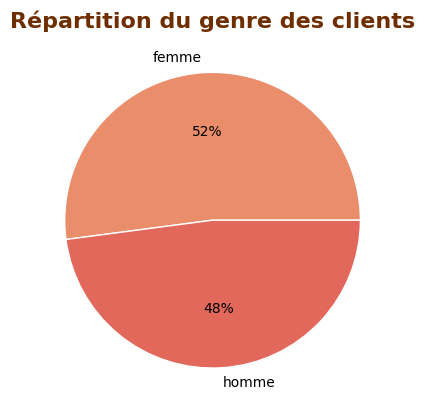

In [9]:
#Répartion du genre des clients
df_repartion_sex = df_customers["sex"].value_counts().reset_index()
plt.pie(
  df_repartion_sex["count"],
  labels = ["femme", "homme"],
  autopct="%.0f%%", 
  colors=sns.color_palette("flare"),
  wedgeprops={'edgecolor': 'white'}
)

plt.title("Répartition du genre des clients", fontsize=16, color="#6F2E00", weight="bold")
plt.show()

In [10]:
#Exploration de la colonne birth
df_customers["birth"].describe()

count    8623.000000
mean     1978.280877
std        16.919535
min      1929.000000
25%      1966.000000
50%      1979.000000
75%      1992.000000
max      2004.000000
Name: birth, dtype: float64

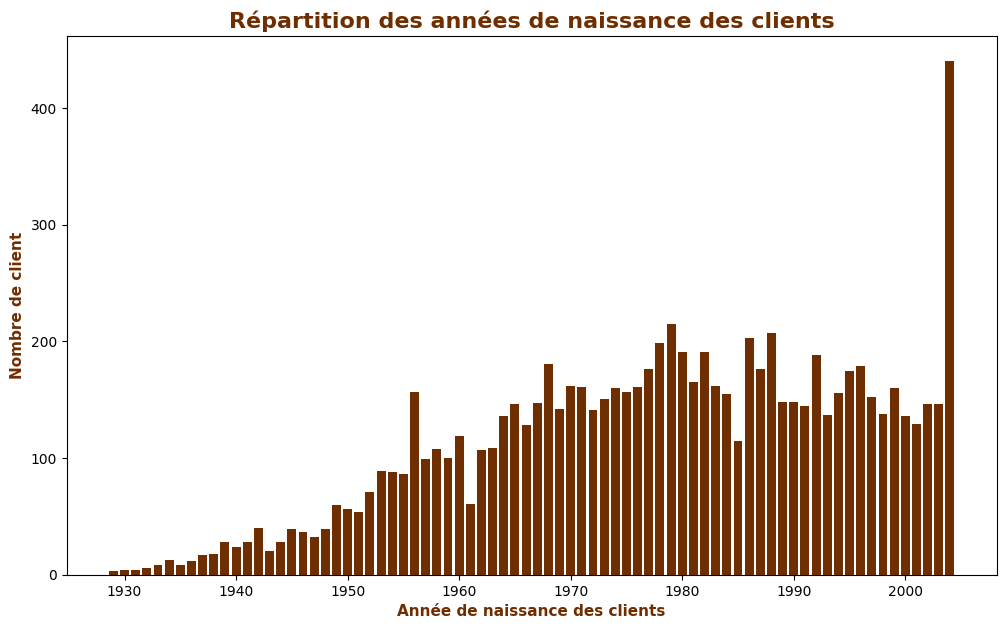

In [11]:
#Répartition de l'année de naissanace
df_repartion_birth = df_customers["birth"].value_counts().reset_index()

plt.figure(figsize=(12, 7))
plt.bar(height=df_repartion_birth["count"], x=df_repartion_birth["birth"], color="#6F2E00")

plt.title("Répartition des années de naissance des clients", fontsize=16, color="#6F2E00", weight="bold")
plt.xlabel("Année de naissance des clients", fontsize=11, color="#6F2E00", weight="bold")
plt.ylabel("Nombre de client", fontsize=11, color="#6F2E00", weight="bold")
plt.show()

In [12]:
#Ajout d'une colonne contenant l'âge des clients
df_customers["age"] = 2026 - df_customers["birth"]

#Ajout de la colonne tranche d'age
df_customers["age_group"] = df_customers["age"].apply(
    lambda x: 
        "[20-29]" if x < 30 else
        "[30-39]" if x < 40 else
        "[40-49]" if x < 50 else
        "[50-59]" if x < 60 else
        "[60-69]" if x < 70 else
        "[70-79]" if x < 80 else
        "[80-89]" if x < 90 else
        "[90-99]"
)

In [13]:
#Rennomage du contenu de la colonne sex
df_customers["sex"] = df_customers["sex"].apply(
    lambda x: 
        "homme" if x=="m" else
        "femme"
)
df_customers.head()

,client_id,sex,birth,age,age_group
0,c_4410,femme,1967,59,[50-59]
1,c_7839,femme,1975,51,[50-59]
2,c_1699,femme,1984,42,[40-49]
3,c_5961,femme,1962,64,[60-69]
4,c_5320,homme,1943,83,[80-89]


In [14]:
#Renommage du nom des colonnes
df_customers = df_customers.rename(columns={'sex': 'gender', 'birth': 'birth_year'})

In [15]:
#Affichage du dataset customer
df_customers.head()

,client_id,gender,birth_year,age,age_group
0,c_4410,femme,1967,59,[50-59]
1,c_7839,femme,1975,51,[50-59]
2,c_1699,femme,1984,42,[40-49]
3,c_5961,femme,1962,64,[60-69]
4,c_5320,homme,1943,83,[80-89]


<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">2.2 - Analyse exploratoire du fichier products.csv</h3>
</div>
 

In [16]:
#Dimension du dataset product
print("Le dataframe products comporte {} lignes".format(df_products.shape[0]))
print("Le dataframe products comporte {} colonnes".format(df_products.shape[1]))

Le dataframe products comporte 3287 lignes
Le dataframe products comporte 3 colonnes


In [17]:
#Consulter le nombre de colonnes
print("Liste des colonnes du dataframe web \n{}".format(list(df_products.columns)))
print("-"*50)

#La nature des données dans chacune des colonnes
print("Nature des colonnes du dataframe web \n{}".format(df_products.dtypes))
print("-"*50)

#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(df_products.columns):
    print("Nombre de valeurs présentes dans la colonne {} : {}".format(column, len(df_products.value_counts(column).reset_index())))


Liste des colonnes du dataframe web 
['id_prod', 'price', 'categ']
--------------------------------------------------
Nature des colonnes du dataframe web 
id_prod     object
price      float64
categ        int64
dtype: object
--------------------------------------------------
Nombre de valeurs présentes dans la colonne id_prod : 3287
Nombre de valeurs présentes dans la colonne price : 1455
Nombre de valeurs présentes dans la colonne categ : 3


In [18]:
print("Affichage des 5 premières lignes du dataframe web")
df_products.head()

Affichage des 5 premières lignes du dataframe web


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [19]:
#Recherche des valeurs manquantes
print(df_products.isnull().sum())

id_prod    0
price      0
categ      0
dtype: int64


In [20]:
#Recherche des identifiants produit en doublon
print("Nombre d'id_prod en doublon {}".format(len(df_products.loc[df_products["id_prod"].duplicated(keep=False),:])))

Nombre d'id_prod en doublon 0


In [21]:
#Renommage des colonnes
df_products = df_products.rename(columns={'id_prod': 'product_id', 'categ': 'category'})

df_products.head()

,product_id,price,category
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Le numéro des catégories correspond au 1er numéro du produit
</p> 
</div>

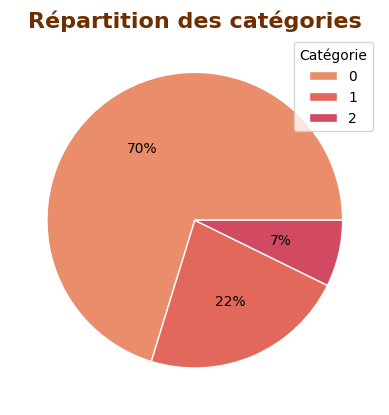

In [22]:
#Répartion de la catégorie
df_repartion_category = df_products["category"].value_counts().reset_index()
plt.pie(
  df_repartion_category["count"],
  autopct="%.0f%%",
  colors=sns.color_palette("flare"),
  wedgeprops={'edgecolor': 'white'}
)

plt.title("Répartition des catégories", fontsize=16, color="#6F2E00", weight="bold")
plt.legend(df_repartion_category["category"], title = "Catégorie")
plt.show()

In [23]:
#Analyse de la colonne price
df_products["price"].describe()

count    3287.000000
mean       21.856641
std        29.847908
min        -1.000000
25%         6.990000
50%        13.060000
75%        22.990000
max       300.000000
Name: price, dtype: float64

In [24]:
#Récupération des prix négatifs
df_products[df_products["price"] <= 0]

,product_id,price,category
731,T_0,-1.0,0


In [25]:
#Suppression du prix négatif
df_products = df_products[df_products["price"] > 0]

#Analyse de la colonne price sans le prix négatif
df_products["price"].describe()

count    3286.000000
mean       21.863597
std        29.849786
min         0.620000
25%         6.990000
50%        13.075000
75%        22.990000
max       300.000000
Name: price, dtype: float64

In [26]:
#Vérification que le numéro de catégorie correspond au 1er numéro du produit
df_products["category_2"] = df_products["product_id"].apply(
    lambda x: int(x[0])
)

somme_category_category_2_identique = (df_products["category"] == df_products["category_2"]).apply(
                                                    lambda x: 1 if x == True else 0
                                                ).sum()
print("{} valeurs sont identiques pour les colonnes category et category_2".format(somme_category_category_2_identique))
print("{} valeurs sont différentes pour les colonnes category et category_2".
      format(df_products.shape[0] - somme_category_category_2_identique))

3286 valeurs sont identiques pour les colonnes category et category_2
0 valeurs sont différentes pour les colonnes category et category_2


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Le numéro des catégories correspond au 1er numéro du produit
</p> 
</div>

In [27]:
#Suppression de la colonne category_2
df_products.drop(columns=["category_2"], inplace=True)

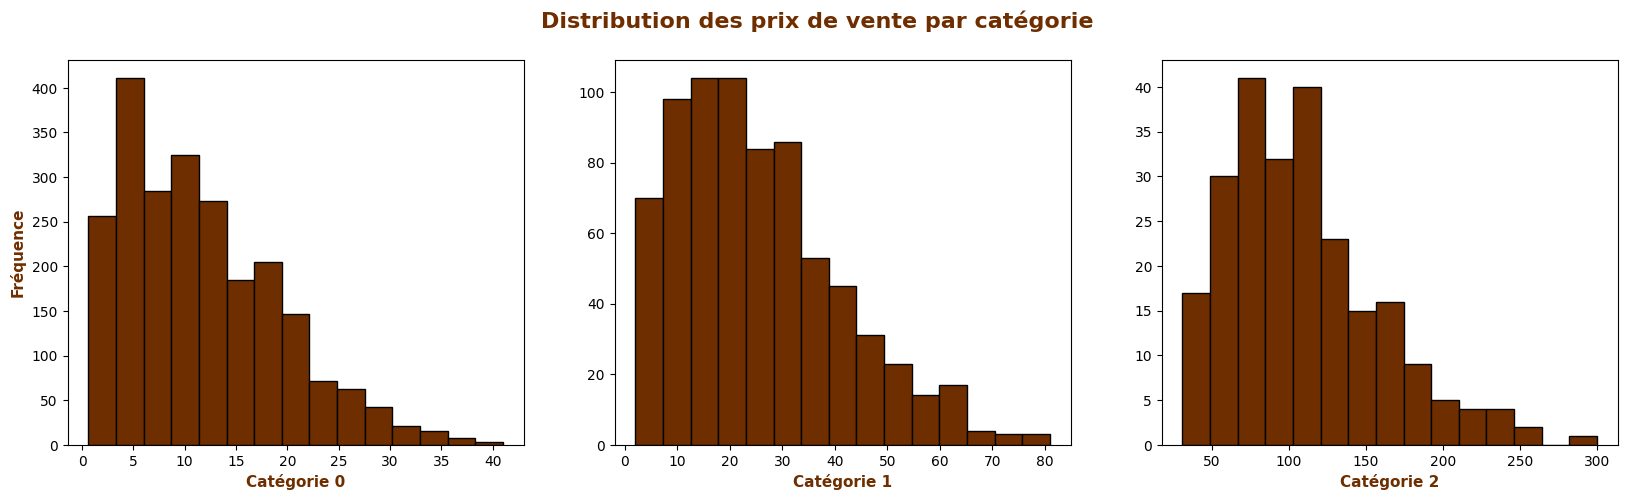

In [28]:
# Répartition des prix par catégorie

#Liste des catégories de produits
categories = df_products["category"].unique()

fig,axes = plt.subplots(1,len(categories))
fig.set_size_inches(20, 5)

for i in range(len(categories)):
    #Dataset des produit filtré par catégorie
    product_by_category = df_products.loc[df_products["category"] == categories[i], :]

    #Histrogramme de répartition des prix par catégorie
    axes[i].hist(product_by_category["price"], bins=15, edgecolor="black", color="#6F2E00")
    
    #Libellé de l'axe des abscisses
    axes[i].set_xlabel('Catégorie ' + str(i), fontsize=11, color="#6F2E00", weight="bold")

#Libellé de l'axe des ordonnées
axes[0].set_ylabel('Fréquence', fontsize=11, color="#6F2E00", weight="bold")

fig.suptitle('Distribution des prix de vente par catégorie', fontsize=16, color="#6F2E00", weight="bold")

plt.show()

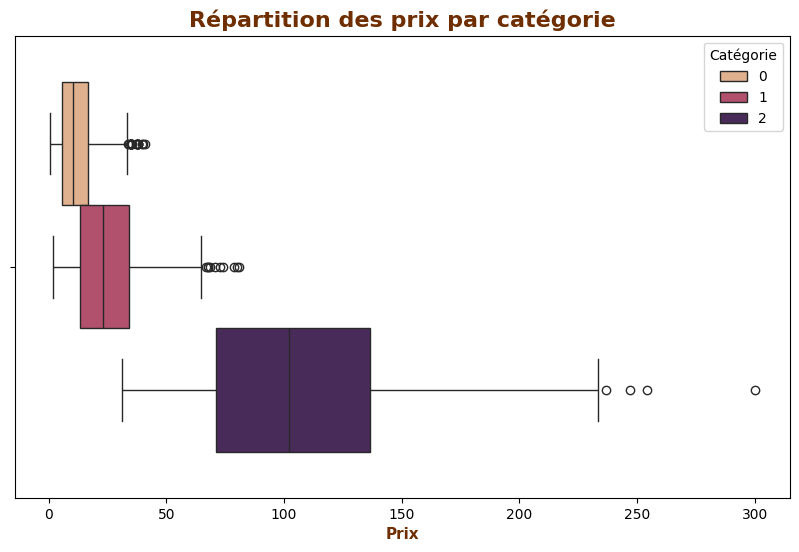

In [29]:
# Graphique en boxplot pour la colonne "price"

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_products, x="price", hue="category", palette="flare")

# Ajouter un titre et des labels
plt.title("Répartition des prix par catégorie", fontsize=16, color="#6F2E00", weight="bold")
plt.xlabel("Prix", fontsize=11, color="#6F2E00", weight="bold")

plt.legend(title = "Catégorie")
# Afficher le graphique
plt.show()

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">2.3 - Analyse exploratoire du fichier transactions.xlsx</h3>
</div>

In [30]:
#Dimension du dataset
#Nombre d"observations
print("Le dataframe transation comporte {} lignes".format(df_transactions.shape[0]))

#Nombre de caractéristiques
print("Le dataframe transation comporte {} colonnes".format(df_transactions.shape[1]))

Le dataframe transation comporte 679532 lignes
Le dataframe transation comporte 4 colonnes


In [31]:
#Consulter le nombre de colonnes
print("Liste des colonnes du dataframe transation {}".format(list(df_transactions.columns)))
print("-"*50)
      
#La nature des données dans chacune des colonnes
print("Nature des colonnes du dataframe transation \n{}".format(df_transactions.dtypes))
print("-"*50)

#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(df_transactions.columns):
    print("Nombre de valeurs présentes dans la colonne {} : {}".format(column, len(df_transactions.value_counts(column).reset_index())))


Liste des colonnes du dataframe transation ['id_prod', 'date', 'session_id', 'client_id']
--------------------------------------------------
Nature des colonnes du dataframe transation 
id_prod       object
date          object
session_id    object
client_id     object
dtype: object
--------------------------------------------------
Nombre de valeurs présentes dans la colonne id_prod : 3267
Nombre de valeurs présentes dans la colonne date : 679371
Nombre de valeurs présentes dans la colonne session_id : 342316
Nombre de valeurs présentes dans la colonne client_id : 8602


In [32]:
#5 première ligne du dataframe transaction
print("5 premières lignes du dataframe transaction")
df_transactions.head()

5 premières lignes du dataframe transaction


,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232


In [33]:
#Recherche des valeurs manquantes
print(df_transactions.isnull().sum())

id_prod       0
date          0
session_id    0
client_id     0
dtype: int64


In [34]:
#Element de la colonne date
df_transactions["date"].value_counts()


date
test_2021-03-01 02:30:02.237413    13
test_2021-03-01 02:30:02.237427     8
test_2021-03-01 02:30:02.237444     8
test_2021-03-01 02:30:02.237428     8
test_2021-03-01 02:30:02.237414     8
                                   ..
2021-05-08 21:49:37.685283          1
2021-12-23 11:28:53.093256          1
2021-09-01 22:30:02.105176          1
2021-11-09 21:41:41.807534          1
2021-05-16 12:49:45.617998          1
Name: count, Length: 679371, dtype: int64

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Les valeurs de la colonne date ne sont pas toutes de type date certaines valeurs commencent par <b>test_</b>
</p>
</div>

In [35]:
#Lignes du dataframe transaction 
df_transactions_date_test = df_transactions[df_transactions["date"].str.startswith("test")]

print("Valeur des colonnes du dataframe transaction ")
df_transactions_date_test.agg({"session_id": "unique", "id_prod":"unique", "client_id":"unique"})

Valeur des colonnes du dataframe transaction 


session_id           [s_0]
id_prod              [T_0]
client_id     [ct_0, ct_1]
dtype: object

In [36]:
print("Nombre de ligne du dataframe transaction contenant un identifiant produit commençant par T_ {}".format(df_transactions[df_transactions["id_prod"].str.startswith("T_")].shape[0]))
print("Nombre de ligne du dataframe transaction contenant un identifiant client commençant par ct_ {}".format(df_transactions[df_transactions["client_id"].str.startswith("ct_")].shape[0]))
print("Nombre de ligne du dataframe transaction contenant une date commençant par test {}".format(df_transactions_date_test.shape[0]))

Nombre de ligne du dataframe transaction contenant un identifiant produit commençant par T_ 200
Nombre de ligne du dataframe transaction contenant un identifiant client commençant par ct_ 200
Nombre de ligne du dataframe transaction contenant une date commençant par test 200


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Le dataframe transaction contient des dates qui commencent par <b>test</b>, ces transactions concerne le produit ayant un prix négatif et concerne les clients commençant par <b>ct_</b>
</p>
</div>

In [37]:
#Suppression des lignes du dataframe transaction qui contiennent des date commençant par test
df_transactions = df_transactions[~df_transactions["date"].str.startswith("test")]

#Suppression des lignes du dataframe customer où la colonne client_id commence par ct_
df_customers = df_customers[~df_customers["client_id"].str.startswith("ct_")]

#Conversion de la colonne date en date
df_transactions["date"] = pd.to_datetime(df_transactions["date"]) 
df_transactions.dtypes

id_prod               object
date          datetime64[ns]
session_id            object
client_id             object
dtype: object

In [38]:
#Analyse de la colonne date
df_transactions["date"].describe()

count                           679332
mean     2022-03-03 15:13:19.307389696
min         2021-03-01 00:01:07.843138
25%      2021-09-08 09:14:25.055994368
50%      2022-03-03 07:50:20.817730560
75%      2022-08-30 23:57:08.555173888
max         2023-02-28 23:58:30.792755
Name: date, dtype: object

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Les dates transaction vont du <b>01/03/2021</b> au <b>28/02/2023</b>
</p>
</div>

In [39]:
#Renommage des colonnes
df_transactions = df_transactions.rename(columns={'id_prod': 'product_id', 'date': 'date_transaction'})

df_transactions.head()

,product_id,date_transaction,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232


<div style="background-color: RGB(160,111,119);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etape 3.1 - Jonction du fichier df_transactions et df_products</h3>
</div>

In [40]:
#Fusion des fichiers transactions et products
print("Fusion gauche des dataframe produit et transaction pour voir si des produits ne sont pas vendus")
df_transations_products = pd.merge(left=df_products, right=df_transactions, on="product_id", how="left")

print("Le merge des dataframe transactions et products possède {} lignes".format(df_transations_products.shape[0]))

df_transations_products.head()


Fusion gauche des dataframe produit et transaction pour voir si des produits ne sont pas vendus
Le merge des dataframe transactions et products possède 679132 lignes


,product_id,price,category,date_transaction,session_id,client_id
0,0_1421,19.99,0,2022-02-20 17:04:37.204937,s_168213,c_6389
1,0_1421,19.99,0,2022-11-19 03:42:20.707442,s_299590,c_8364
2,0_1421,19.99,0,2021-09-19 14:58:46.726179,s_92304,c_3544
3,0_1421,19.99,0,2023-01-11 16:04:24.367855,s_325369,c_1025
4,0_1421,19.99,0,2021-08-01 19:33:18.877168,s_70071,c_2298


In [41]:
#Recherche des valeurs manquantes
df_missing_data = df_transations_products.isnull()
print("Liste des colonnes ayant des données manquantes")
print(df_missing_data.sum())

Liste des colonnes ayant des données manquantes
product_id           0
price                0
category             0
date_transaction    21
session_id          21
client_id           21
dtype: int64


In [42]:
#Recherche des lignes contenant des valeurs manquantes
df_missing_rows = df_missing_data.any(axis=1)
print("Nombre de ligne ayant des données manquantes {}".format(df_missing_rows.sum()))

Nombre de ligne ayant des données manquantes 21


In [43]:
print("Liste des produits non vendus")
no_sales_product_list = list(df_transations_products[df_transations_products["session_id"].isnull()]["product_id"])
no_sales_product_list

Liste des produits non vendus


['0_1016',
 '0_1780',
 '0_1062',
 '0_1119',
 '0_1014',
 '1_0',
 '0_1318',
 '0_1800',
 '0_1645',
 '0_322',
 '0_1620',
 '0_1025',
 '2_87',
 '1_394',
 '2_72',
 '0_310',
 '0_1624',
 '2_86',
 '0_299',
 '0_510',
 '0_2308']

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Il y a 21 produits qui ne sont pas vendus 
</p> 
</div>

In [44]:
#Pourcentage des produits non vendus
print("Pourcentage des produits non vendus {:.2%}".format(df_missing_rows.sum() / df_products.shape[0]))

#Caractéristiques des produits non vendus
print("Caractéristiques des produits non vendus")
df_products[df_products["product_id"].isin(no_sales_product_list)]

Pourcentage des produits non vendus 0.64%
Caractéristiques des produits non vendus


,product_id,price,category
184,0_1016,35.06,0
279,0_1780,1.67,0
737,0_1062,20.08,0
794,0_1119,2.99,0
811,0_1014,1.15,0
846,1_0,31.82,1
1031,0_1318,20.92,0
1139,0_1800,22.05,0
1347,0_1645,2.99,0
1505,0_322,2.99,0


In [45]:
#Fusion des fichiers transactions et products
print("Fusion gauche des dataframe transaction et produit pour voir si des transaction ne correspondent à aucun produits")

df_transations_products = pd.merge(left=df_transactions, right=df_products, on="product_id", how="left")

print("Le merge des dataframe transactions et products possède {} lignes".format(df_transations_products.shape[0]))

df_transations_products.head()


Fusion gauche des dataframe transaction et produit pour voir si des transaction ne correspondent à aucun produits
Le merge des dataframe transactions et products possède 679332 lignes


,product_id,date_transaction,session_id,client_id,price,category
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0.0
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1.0
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0.0
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2.0
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0.0


In [46]:
#Recherche des valeurs manquantes
print(df_transations_products.isnull().sum())

product_id            0
date_transaction      0
session_id            0
client_id             0
price               221
category            221
dtype: int64


In [47]:
#Recherche des lignes contenant des valeurs manquantes
df_missing_data = df_transations_products.isnull()
df_missing_rows = df_missing_data.any(axis=1)
print("Nombre de ligne ayant des données manquantes {}".format(df_missing_rows.sum()))

Nombre de ligne ayant des données manquantes 221


In [48]:
products_with_no_price = df_transations_products[df_transations_products["price"].isnull()]["product_id"].unique()
print("Produit vendu qui n'est pas présent dans la le dataframe produit")
products_with_no_price

Produit vendu qui n'est pas présent dans la le dataframe produit


array(['0_2245'], dtype=object)

In [49]:
df_transations_products[df_transations_products["category"].isnull()]["product_id"].unique()

array(['0_2245'], dtype=object)

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Le produit 0_2245 se trouve dans le dataframe transaction mais n'est pas dans le dataframe product
</p> 
</div>

In [50]:
#Ajout dans le dataframe transaction du prix du produit 0_2245 qui est la médiane des produits de la catégorie 0 et ajout de la catégorie 0

median_price_catagorie_0 = df_products[df_products["category"] == 0]["price"].median()
df_transations_products.loc[df_transations_products["product_id"] == "0_2245", "category"] = 0
df_transations_products.loc[df_transations_products["product_id"] == "0_2245", "price"] = median_price_catagorie_0

print("Transaction du produit 0_2245")
df_transations_products[df_transations_products["product_id"] == "0_2245"].head()

Transaction du produit 0_2245


,product_id,date_transaction,session_id,client_id,price,category
2633,0_2245,2022-09-23 07:22:38.636773,s_272266,c_4746,10.32,0.0
10103,0_2245,2022-07-23 09:24:14.133889,s_242482,c_6713,10.32,0.0
11723,0_2245,2022-12-03 03:26:35.696673,s_306338,c_5108,10.32,0.0
15670,0_2245,2021-08-16 11:33:25.481411,s_76493,c_1391,10.32,0.0
16372,0_2245,2022-07-16 05:53:01.627491,s_239078,c_7954,10.32,0.0


In [51]:
#Modification du format de la colonne category
df_transations_products["category"] = df_transations_products["category"].astype(int)
df_transations_products["category"].dtypes

dtype('int64')

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etape 3.2 - Jonction du fichier df_transaction_products et df_customers</h3>
</div>

In [52]:
#Fusion des fichiers customer et products
print("Fusion gauche des dataframe customer et transaction pour voir si des produits ne sont pas vendus")
df_detail_transactions = pd.merge(left=df_customers, right=df_transations_products, on="client_id", how="left")

print("Le merge des dataframe des dataframe transaction, produit et customer possède {} lignes".format(df_detail_transactions.shape[0]))

df_transations_products.head()

Fusion gauche des dataframe customer et transaction pour voir si des produits ne sont pas vendus
Le merge des dataframe des dataframe transaction, produit et customer possède 679353 lignes


,product_id,date_transaction,session_id,client_id,price,category
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0


In [53]:
#Recherche des valeurs manquantes
df_missing_data = df_detail_transactions.isnull()
print("Liste des colonnes ayant des données manquantes")
print(df_missing_data.sum())

Liste des colonnes ayant des données manquantes
client_id            0
gender               0
birth_year           0
age                  0
age_group            0
product_id          21
date_transaction    21
session_id          21
price               21
category            21
dtype: int64


In [54]:
#Recherche des lignes contenant des valeurs manquantes
df_missing_rows = df_missing_data.any(axis=1)
print("Nombre de ligne ayant des données manquantes {}".format(df_missing_rows.sum()))

Nombre de ligne ayant des données manquantes 21


In [55]:
print("Liste des clients n'ayant fait aucun achat")
no_purcharse_client_list = list(df_detail_transactions[df_detail_transactions["session_id"].isnull()]["client_id"])
no_purcharse_client_list

Liste des clients n'ayant fait aucun achat


['c_8253',
 'c_3789',
 'c_4406',
 'c_2706',
 'c_3443',
 'c_4447',
 'c_3017',
 'c_4086',
 'c_6930',
 'c_4358',
 'c_8381',
 'c_1223',
 'c_6862',
 'c_5245',
 'c_5223',
 'c_6735',
 'c_862',
 'c_7584',
 'c_90',
 'c_587',
 'c_3526']

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Il y a 21 clients qui n'ont fait aucun achat
</p> 
</div>

In [56]:
#Pourcentage des produits non vendus
print("Pourcentage des client n'ayant pas fait d'achat {:.2%}".format(df_missing_rows.sum() / df_customers.shape[0]))

#Caratéristique des clients n'ayant pas fait d'achat
df_customers[df_customers["client_id"].isin(no_purcharse_client_list)]

Pourcentage des client n'ayant pas fait d'achat 0.24%


,client_id,gender,birth_year,age,age_group
801,c_8253,femme,2001,25,[20-29]
2483,c_3789,femme,1997,29,[20-29]
2734,c_4406,femme,1998,28,[20-29]
2769,c_2706,femme,1967,59,[50-59]
2851,c_3443,homme,1959,67,[60-69]
3179,c_4447,homme,1956,70,[70-79]
3190,c_3017,femme,1992,34,[30-39]
3334,c_4086,femme,1992,34,[30-39]
3721,c_6930,homme,2004,22,[20-29]
3821,c_4358,homme,1999,27,[20-29]


In [57]:
#Fusionner les datasets df_transations_products et df_customers
df_detail_transactions = pd.merge(left=df_transations_products, right=df_customers, left_on="client_id", right_on="client_id", how="left")

print("Le merge des dataframe transaction, produit et customer possède {} lignes".format(df_detail_transactions.shape[0]))

print("Affichage des 5 premières lignes du dataset mergé")

display(df_detail_transactions.head())


Le merge des dataframe transaction, produit et customer possède 679332 lignes
Affichage des 5 premières lignes du dataset mergé


,product_id,date_transaction,session_id,client_id,price,category,gender,birth_year,age,age_group
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0,femme,1986,40,[40-49]
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1,homme,1988,38,[30-39]
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0,femme,1968,58,[50-59]
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2,homme,2000,26,[20-29]
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0,homme,1980,46,[40-49]


In [58]:
#Recherche des valeurs manquantes
print(df_detail_transactions.isnull().sum())

product_id          0
date_transaction    0
session_id          0
client_id           0
price               0
category            0
gender              0
birth_year          0
age                 0
age_group           0
dtype: int64


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Les clients présents dans le dataframe de transaction sont présent dans le dataframe customer
</p> 
</div>

<div style="background-color: RGB(160,111,119);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse du chiffre d'affaire</h2>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etape 4.1 - Chiffre d'affaire total</h3>
</div>

In [59]:
#Chiffre d'affaire total
ca_total = df_detail_transactions["price"].sum()
print("Chiffre d'affaire de la librairie {:,.2f} €".format(ca_total))

Chiffre d'affaire de la librairie 11,856,009.40 €


In [60]:
#Ajout d"une colonne contenant le mois d'achat
df_detail_transactions["month_transaction"] = df_detail_transactions["date_transaction"].dt.to_period("M").dt.to_timestamp()
df_detail_transactions["only_month_transaction"] = df_detail_transactions["date_transaction"].dt.month_name(locale="fr_FR.utf8")

df_detail_transactions.head()

,product_id,date_transaction,session_id,client_id,price,category,gender,birth_year,age,age_group,month_transaction,only_month_transaction
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0,femme,1986,40,[40-49],2022-05-01,Mai
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1,homme,1988,38,[30-39],2022-02-01,Fã©vrier
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0,femme,1968,58,[50-59],2022-06-01,Juin
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2,homme,2000,26,[20-29],2021-06-01,Juin
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0,homme,1980,46,[40-49],2023-01-01,Janvier


In [61]:
#Ajout d'une colonne period qui vaut period_1 pour les ventes entre le 01/03/2021 et le 28/02/2022 et period_2 pour les ventes entre le  01/03/2022 et le 28/02/2023

start_date_period_1 = pd.to_datetime("01/03/2021", format="%d/%m/%Y")
end_date_period_1 =  pd.to_datetime("28/02/2022", format="%d/%m/%Y")
start_date_period_2 =  pd.to_datetime("01/03/2022", format="%d/%m/%Y")
end_date_period_2 =  pd.to_datetime("28/02/2023", format="%d/%m/%Y")
df_detail_transactions["period"] = df_detail_transactions["month_transaction"].apply(
    lambda x: 
        "period_1" if (x>= start_date_period_1 and x <= end_date_period_1) else
        "period_2"
)
df_detail_transactions.head()

,product_id,date_transaction,session_id,client_id,price,category,gender,birth_year,age,age_group,month_transaction,only_month_transaction,period
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0,femme,1986,40,[40-49],2022-05-01,Mai,period_2
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1,homme,1988,38,[30-39],2022-02-01,Fã©vrier,period_1
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0,femme,1968,58,[50-59],2022-06-01,Juin,period_2
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2,homme,2000,26,[20-29],2021-06-01,Juin,period_1
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0,homme,1980,46,[40-49],2023-01-01,Janvier,period_2


In [62]:
#Ajout d'une colonne contenant le jour de la transation
df_detail_transactions["day_transaction"] = df_detail_transactions["date_transaction"].dt.to_period("D").dt.to_timestamp()

df_detail_transactions["only_day_transaction"] = df_detail_transactions["date_transaction"].dt.day_name(locale="fr_FR.utf8")
df_detail_transactions.head()

,product_id,date_transaction,session_id,client_id,price,category,gender,birth_year,age,age_group,month_transaction,only_month_transaction,period,day_transaction,only_day_transaction
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0,femme,1986,40,[40-49],2022-05-01,Mai,period_2,2022-05-20,Vendredi
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1,homme,1988,38,[30-39],2022-02-01,Fã©vrier,period_1,2022-02-02,Mercredi
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0,femme,1968,58,[50-59],2022-06-01,Juin,period_2,2022-06-18,Samedi
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2,homme,2000,26,[20-29],2021-06-01,Juin,period_1,2021-06-24,Jeudi
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0,homme,1980,46,[40-49],2023-01-01,Janvier,period_2,2023-01-11,Mercredi


In [63]:
#Ajout d'une colonne contenant l'heure de la transation
df_detail_transactions["hour_transaction"] = df_detail_transactions["date_transaction"].dt.hour
df_detail_transactions.head()

,product_id,date_transaction,session_id,client_id,price,category,gender,birth_year,age,age_group,month_transaction,only_month_transaction,period,day_transaction,only_day_transaction,hour_transaction
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0,femme,1986,40,[40-49],2022-05-01,Mai,period_2,2022-05-20,Vendredi,13
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1,homme,1988,38,[30-39],2022-02-01,Fã©vrier,period_1,2022-02-02,Mercredi,7
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0,femme,1968,58,[50-59],2022-06-01,Juin,period_2,2022-06-18,Samedi,15
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2,homme,2000,26,[20-29],2021-06-01,Juin,period_1,2021-06-24,Jeudi,4
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0,homme,1980,46,[40-49],2023-01-01,Janvier,period_2,2023-01-11,Mercredi,8


In [64]:
#Chiffre d'affaire par periode
df_detail_transactions_period_1 = df_detail_transactions[df_detail_transactions["period"] == "period_1"]
ca_total_period_1 = df_detail_transactions_period_1["price"].sum()
print("Chiffre d'affaire de la librairie du 01/03/2021 au 28/02/2022 {:,.2f} €".format(ca_total_period_1))

df_detail_transactions_period_2 = df_detail_transactions[df_detail_transactions["period"] == "period_2"]
ca_total_period_2 = df_detail_transactions_period_2["price"].sum()
print("Chiffre d'affaire de la librairie du 01/03/2022 au 28/02/2023 {:,.2f} €".format(ca_total_period_2))

Chiffre d'affaire de la librairie du 01/03/2021 au 28/02/2022 5,832,800.01 €
Chiffre d'affaire de la librairie du 01/03/2022 au 28/02/2023 6,023,209.39 €


<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etape 4.2 - Chiffre d'affaire dans le temps</h3>
</div>

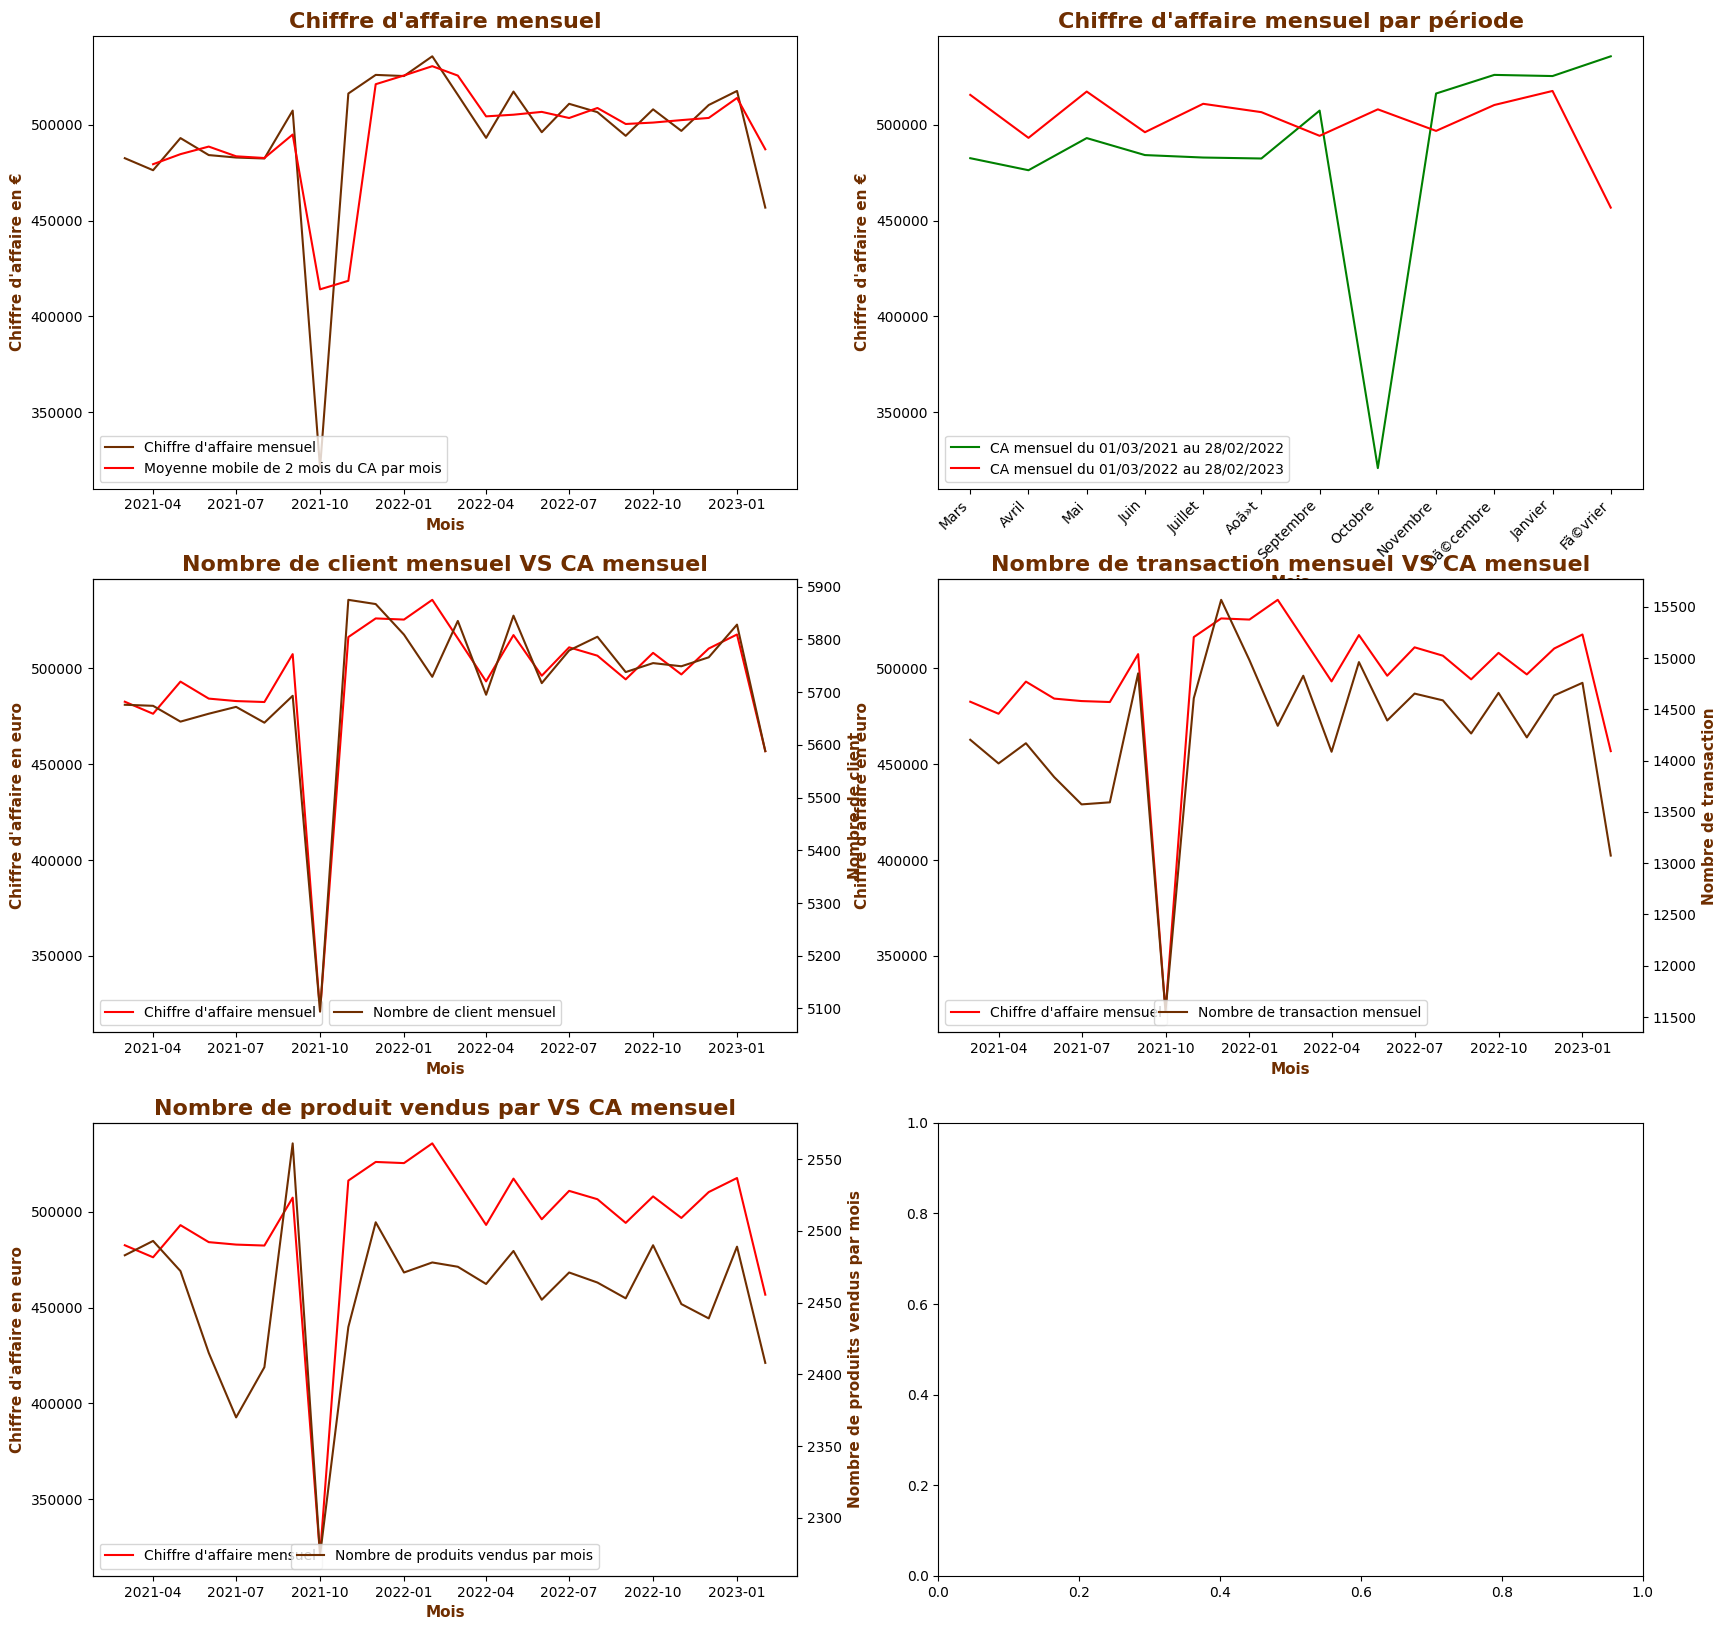

In [65]:
#Groupe de graphique contenant les évolutions du chiffre d'affaire, le nombre de client, le nombre de transacrion et le nombre de produits vendus par mois
fig,axes = plt.subplots(3,2)
fig.set_size_inches(20, 20)

#--------------------------------------------------------------------------#
# Chiffre d'affaire par mois et moyenne mobile
#--------------------------------------------------------------------------#

#dataset contenant le CA mensuel
df_turnover_by_month = df_detail_transactions.groupby("month_transaction")["price"].sum().reset_index(name="turnover").sort_values("month_transaction")
axes[0,0].plot(df_turnover_by_month["month_transaction"],df_turnover_by_month["turnover"], color="#6F2E00", label="Chiffre d'affaire mensuel")
#Moyenne mobile
axes[0,0].plot(df_turnover_by_month["month_transaction"], df_turnover_by_month["turnover"].rolling(2).mean(), color="red", label="Moyenne mobile de 2 mois du CA par mois")

axes[0,0].set_title("Chiffre d'affaire mensuel", fontsize=16, color="#6F2E00", weight="bold")
axes[0,0].set_xlabel("Mois", fontsize=11, color="#6F2E00", weight="bold")
axes[0,0].set_ylabel("Chiffre d'affaire en €", fontsize=11, color="#6F2E00", weight="bold")
axes[0,0].legend(loc="lower left")

#--------------------------------------------------------------------------#
# Chiffre d'affaire par période
#--------------------------------------------------------------------------#

#Dataset contenant le CA de le période du 01/03/2021 au 28/02/2022
df_turnover_by_month_period_1 = df_detail_transactions_period_1.groupby(["month_transaction", "only_month_transaction"])["price"].sum().reset_index(name="turnover").sort_values("month_transaction")
#Dataset contenant le CA de le période du 01/03/2022 au 28/02/2023
df_turnover_by_month_period_2 = df_detail_transactions_period_2.groupby(["month_transaction", "only_month_transaction"])["price"].sum().reset_index(name="turnover").sort_values("month_transaction")

axes[0,1].plot(df_turnover_by_month_period_1["only_month_transaction"], df_turnover_by_month_period_1["turnover"], color="green", label="CA mensuel du 01/03/2021 au 28/02/2022")
axes[0,1].plot(df_turnover_by_month_period_2["only_month_transaction"], df_turnover_by_month_period_2["turnover"], color="red", label="CA mensuel du 01/03/2022 au 28/02/2023")

axes[0,1].set_title("Chiffre d'affaire mensuel par période", fontsize=16, color="#6F2E00", weight="bold")
axes[0,1].set_xlabel("Mois", fontsize=11, color="#6F2E00", weight="bold")
axes[0,1].set_ylabel("Chiffre d'affaire en €", fontsize=11, color="#6F2E00", weight="bold")
axes[0,1].legend(loc="lower left")

for label in axes[0,1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

#--------------------------------------------------------------------------#
# Comparaison du nombre de client par mois et du chiffre d'affaire par mois
#--------------------------------------------------------------------------#

#Dataset contenant le nombre de client par mois
df_nb_customer_by_month = df_detail_transactions.groupby('month_transaction')['client_id'].nunique().reset_index(name="nb_client").sort_values("month_transaction")

#Graphique linéaire contenant l'évolution du CA par mois
axes[1,0].plot(df_turnover_by_month["month_transaction"],df_turnover_by_month["turnover"], color="red", label="Chiffre d'affaire mensuel")
axes[1,0].set_title("Nombre de client mensuel VS CA mensuel", fontsize=16, color="#6F2E00", weight="bold")

axes[1,0].set_xlabel("Mois", fontsize=11, color="#6F2E00", weight="bold")
axes[1,0].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")
axes[1,0].legend(loc="lower left")

#Ajout dans le même graphique le nombre de client par mois
ax_1_0_twin = axes[1,0].twinx()
ax_1_0_twin.plot(df_nb_customer_by_month["month_transaction"], df_nb_customer_by_month["nb_client"], color="#6F2E00", label="Nombre de client mensuel")

ax_1_0_twin.set_ylabel("Nombre de client", fontsize=11, color="#6F2E00", weight="bold")
ax_1_0_twin.legend(loc="lower center")

#-------------------------------------------------------------------------------#
# Comparaison du nombre de transaction par mois et du chiffre d'affaire par mois
#-------------------------------------------------------------------------------#

#Dataset contenant le nombre de transaction par mois
df_nb_transactions_by_month = df_detail_transactions.groupby('month_transaction')['session_id'].nunique().reset_index(name="nb_transaction").sort_values("month_transaction")

#Graphique linéaire contenant l'évolution du CA par mois
axes[1,1].plot(df_turnover_by_month["month_transaction"],df_turnover_by_month["turnover"], color="red", label="Chiffre d'affaire mensuel")
axes[1,1].set_title("Nombre de transaction mensuel VS CA mensuel", fontsize=16, color="#6F2E00", weight="bold")

axes[1,1].set_xlabel("Mois", fontsize=11, color="#6F2E00", weight="bold")
axes[1,1].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")
axes[1,1].legend(loc="lower left")

#Ajout dans le même graphique le nombre de transaction par mois
ax_1_1_twin = axes[1,1].twinx()
ax_1_1_twin.plot(df_nb_transactions_by_month["month_transaction"], df_nb_transactions_by_month["nb_transaction"], color="#6F2E00", label="Nombre de transaction mensuel")

ax_1_1_twin.set_ylabel("Nombre de transaction", fontsize=11, color="#6F2E00", weight="bold")
ax_1_1_twin.legend(loc="lower center")

#----------------------------------------------------------------------------------#
# Comparaison du nombre de produit vendus par mois et du chiffre d'affaire par mois
#----------------------------------------------------------------------------------#

#Dataset contenant le nombre de transaction par mois
df_nb_sales_product_by_month = df_detail_transactions.groupby("month_transaction")["product_id"].nunique().reset_index(name="nb_sales_product").sort_values("month_transaction")

#Graphique linéaire contenant l'évolution du CA par mois
axes[2,0].plot(df_turnover_by_month["month_transaction"],df_turnover_by_month["turnover"], color="red", label="Chiffre d'affaire mensuel")
axes[2,0].set_title("Nombre de produit vendus par VS CA mensuel", fontsize=16, color="#6F2E00", weight="bold")

axes[2,0].set_xlabel("Mois", fontsize=11, color="#6F2E00", weight="bold")
axes[2,0].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")
axes[2,0].legend(loc="lower left")

#Ajout dans le même graphique le nombre de produit vendus par mois
ax_2_0_twin = axes[2,0].twinx()
ax_2_0_twin.plot(df_nb_sales_product_by_month["month_transaction"], df_nb_sales_product_by_month["nb_sales_product"], color="#6F2E00", label="Nombre de produits vendus par mois")

ax_2_0_twin.set_ylabel("Nombre de produits vendus par mois", fontsize=11, color="#6F2E00", weight="bold")
ax_2_0_twin.legend(loc="lower center")

plt.show()


<div>
<p style="margin: auto; padding: 20px; color: RGB(160,111,119);">
On constate une baisse des ventes en octobre 2021
</p>
</div>

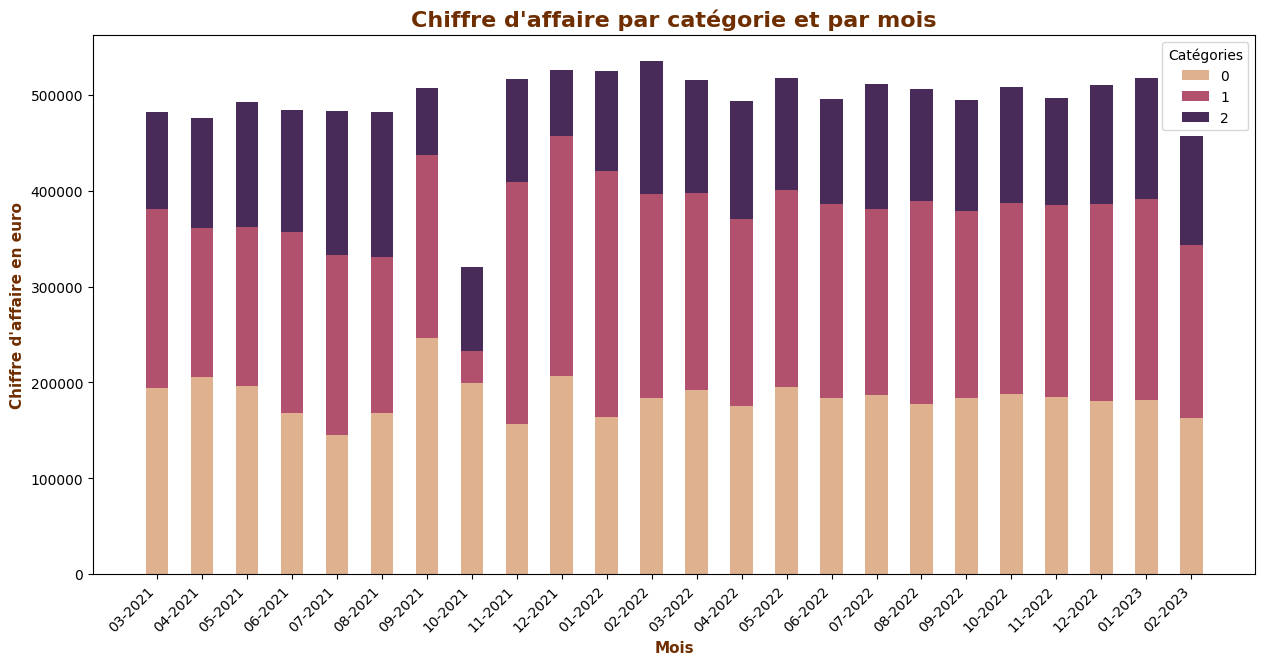

In [66]:
#CA par mois et par catégorie
df_turnover_by_month_and_category = df_detail_transactions.groupby(["month_transaction","category"])["price"].sum().reset_index(name="turnover").sort_values("month_transaction")

#Diagramme empilé représentant le chiffre d'affaire par mois et catégorie
fig, axes = plt.subplots()
fig.set_size_inches(15, 7)

#List des mois
month_list = df_turnover_by_month_and_category["month_transaction"].unique()

#Libelle des mois
month_label_list = df_turnover_by_month_and_category["month_transaction"].dt.to_period("M").unique().strftime("%m-%Y")

#Position des mois dans le graphique
bar_position = np.arange(len(month_list))

#Position de la bar basse
bottom = np.zeros(len(month_list))

#Taille de l'axe des abscisses
axes.set_xticks(np.arange(len(month_list)))
axes.set_xticklabels(month_label_list, rotation=45, ha='right')

#Couleur des barres selon la catégorie
bar_colors=["#DFB18E", "#B1516E","#492B5A"]

category_list = df_turnover_by_month_and_category["category"].unique()
#Affichage des barres
for i in range(len(category_list)):
    turnover_category_list = df_turnover_by_month_and_category[df_turnover_by_month_and_category["category"] == category_list[i]]["turnover"]
    axes.bar(x=bar_position, height = turnover_category_list, width=0.5, label=category_list[i], bottom=bottom, color=bar_colors[i])
    bottom = np.add(bottom, turnover_category_list).tolist()

#Titre et légende du graphique
axes.set_title("Chiffre d'affaire par catégorie et par mois",  fontsize=16, color="#6F2E00", weight="bold")
axes.set_xlabel("Mois", fontsize=11, color="#6F2E00", weight="bold")
axes.set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")
axes.legend(title='Catégories')


plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(160,111,119);">
On constate qu'en octobre 2021 il y a eu très peu de produit de la catégorie 1 qui ont été vendu
</p>
</div>

In [67]:
first_day_oct_2021 = datetime.datetime(2021, 10, 1)
last_day_oct_2021 = datetime.datetime(2021, 10, 31)
df_detail_transaction_category_1_octobre_2021 = df_detail_transactions[(df_detail_transactions["category"]==1) & (df_detail_transactions["day_transaction"]>=first_day_oct_2021) & (df_detail_transactions["day_transaction"]<=last_day_oct_2021)]

In [68]:
df_detail_transaction_category_1_octobre_2021.groupby("day_transaction").agg({"session_id": "nunique","product_id": "nunique","client_id": "nunique","price":"sum"}).reset_index()


,day_transaction,session_id,product_id,client_id,price
0,2021-10-01,271,188,246,7003.79
1,2021-10-28,252,186,236,6317.99
2,2021-10-29,258,183,240,6425.18
3,2021-10-30,259,195,248,6753.69
4,2021-10-31,257,187,246,7261.67


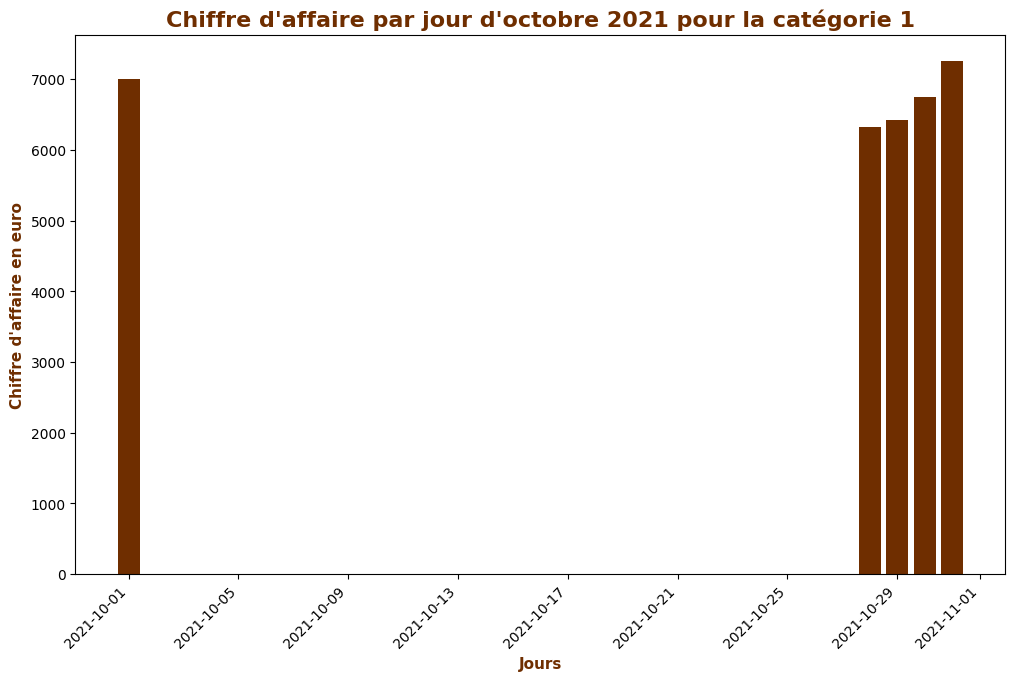

In [69]:
#CA des produits de la category 1 du mois d'octobre
df_turnover_by_day_category_1_octobre_2021 = df_detail_transaction_category_1_octobre_2021.groupby("day_transaction")["price"].sum().reset_index(name="turnover").sort_values("day_transaction")
df_turnover_by_day_category_1_octobre_2021["day_transaction"]

plt.figure(figsize=(12, 7))
plt.bar(height=df_turnover_by_day_category_1_octobre_2021["turnover"], x=df_turnover_by_day_category_1_octobre_2021["day_transaction"], color="#6F2E00")

#Titre et légende du graphique
plt.title("Chiffre d'affaire par jour d'octobre 2021 pour la catégorie 1",  fontsize=16, color="#6F2E00", weight="bold")
plt.xlabel("Jours", fontsize=11, color="#6F2E00", weight="bold")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(160,111,119);">
En octobre 2021 les produits de la catégories 1 ont été vendus sur 5 jours
<br />
Il manque les données du 02 au 27 octobre 2021
<br />
Le CA du mois d'octobre 2021 sera calculé par la moyenne du CA de septembre 2021 et celle de novembre 2021
</p>
</div>

In [70]:
#Calcul du CA du mois d'octobre 2021 qui est la moyenne du CA de septembre 2021 et celle de novembre 2021
turnover_september_2021 = df_turnover_by_month[df_turnover_by_month["month_transaction"] == "2021-09-01"]["turnover"].item()
turnover_november_2021 = df_turnover_by_month[df_turnover_by_month["month_transaction"] == "2021-11-01"]["turnover"].item()

turnover_october_2021_new = (turnover_september_2021 + turnover_november_2021) / 2
df_turnover_by_month.loc[df_turnover_by_month["month_transaction"] == "2021-10-01", "turnover"] = turnover_october_2021_new

In [71]:
#Calcul du CA du mois d'octobre 2021 qui est la moyenne du CA de septembre 2021 et celle de novembre 2021
turnover_september_2021 = df_turnover_by_month_period_1[df_turnover_by_month_period_1["month_transaction"] == "2021-09-01"]["turnover"].item()
turnover_november_2021 = df_turnover_by_month_period_1[df_turnover_by_month_period_1["month_transaction"] == "2021-11-01"]["turnover"].item()

turnover_october_2021_new = (turnover_september_2021 + turnover_november_2021) / 2
df_turnover_by_month_period_1.loc[df_turnover_by_month_period_1["month_transaction"] == "2021-10-01", "turnover"] = turnover_october_2021_new

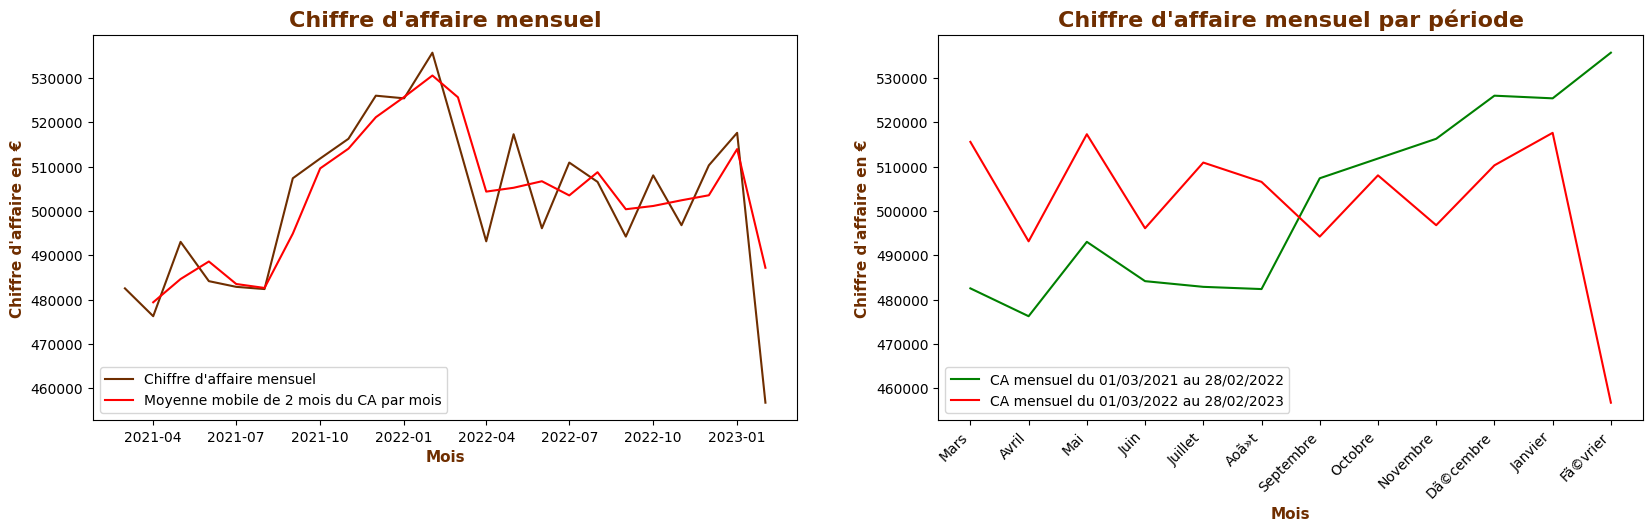

In [72]:
#Groupe de graphique contenant les évolutions du chiffre d'affaire, le nombre de client, le nombre de transacrion et le nombre de produits vendus par mois
fig,axes = plt.subplots(1,2)
fig.set_size_inches(20, 5)

#--------------------------------------------------------------------------#
# Chiffre d'affaire par mois et moyenne mobile
#--------------------------------------------------------------------------#

axes[0].plot(df_turnover_by_month["month_transaction"],df_turnover_by_month["turnover"], color="#6F2E00", label="Chiffre d'affaire mensuel")
#Moyenne mobile
axes[0].plot(df_turnover_by_month["month_transaction"], df_turnover_by_month["turnover"].rolling(2).mean(), color="red", label="Moyenne mobile de 2 mois du CA par mois")

axes[0].set_title("Chiffre d'affaire mensuel", fontsize=16, color="#6F2E00", weight="bold")
axes[0].set_xlabel("Mois", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_ylabel("Chiffre d'affaire en €", fontsize=11, color="#6F2E00", weight="bold")
axes[0].legend(loc="lower left")

#--------------------------------------------------------------------------#
# Chiffre d'affaire par période
#--------------------------------------------------------------------------#

axes[1].plot(df_turnover_by_month_period_1["only_month_transaction"], df_turnover_by_month_period_1["turnover"], color="green", label="CA mensuel du 01/03/2021 au 28/02/2022")
axes[1].plot(df_turnover_by_month_period_2["only_month_transaction"], df_turnover_by_month_period_2["turnover"], color="red", label="CA mensuel du 01/03/2022 au 28/02/2023")

axes[1].set_title("Chiffre d'affaire mensuel par période", fontsize=16, color="#6F2E00", weight="bold")
axes[1].set_xlabel("Mois", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_ylabel("Chiffre d'affaire en €", fontsize=11, color="#6F2E00", weight="bold")
axes[1].legend(loc="lower left")

for label in axes[1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

plt.show()


<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etape 4.2 - Chiffre d'affaire par catégorie</h3>
</div>

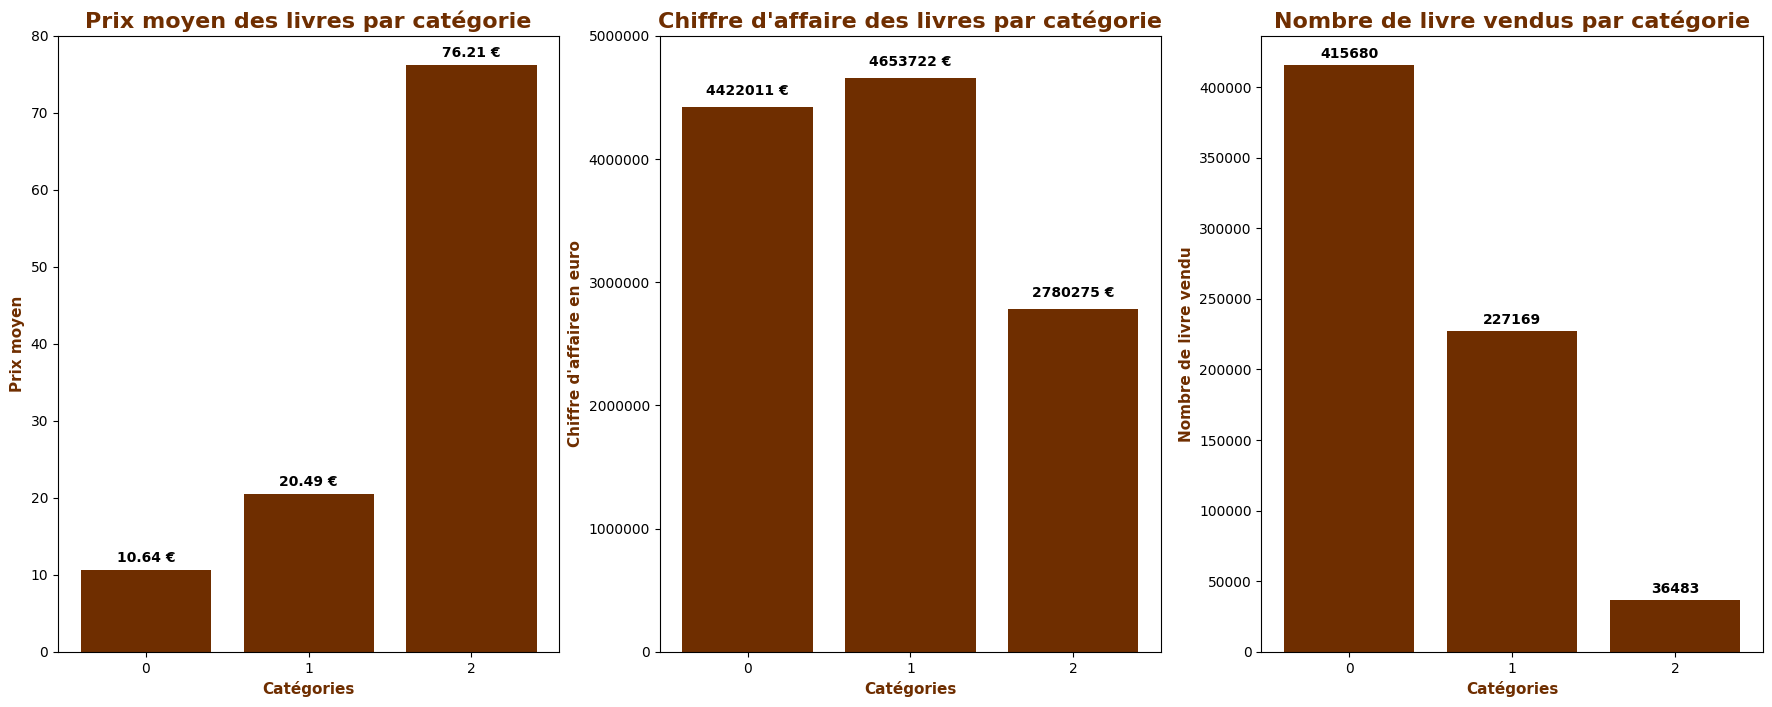

In [73]:
#Comparaison du chiffre d'affaire par catégorie, du prix moins par catégorie et de la quantité vendue par catégorie

#Prix moyen des produits par catégorie
df_avg_price_by_category = df_detail_transactions.groupby("category")["price"].mean().reset_index(name="avg_price")

#CA des produits par catégorie
df_turnover_by_category = df_detail_transactions.groupby("category")["price"].sum().reset_index(name="turnover")

#Nombre de produit vendus par catégorie
df_nb_product_by_category = df_detail_transactions["category"].value_counts().reset_index(name="nb_products")

fig, axes = plt.subplots(1,3)
fig.set_size_inches(22, 8)

#Graphique en barre représentant le prix moyen par catégorie
axes[0].bar(x= df_avg_price_by_category["category"], height=df_avg_price_by_category["avg_price"], color="#6F2E00")

axes[0].set_title("Prix moyen des livres par catégorie", fontsize=16, color="#6F2E00", weight="bold")
axes[0].set_xlabel("Catégories", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_ylabel("Prix moyen", fontsize=11, color="#6F2E00", weight="bold")
#Valeurs de l'axe des absisse
axes[0].set_xticks([0,1,2])

#Ajout des labels sur les barres
for i, valeur in enumerate(df_avg_price_by_category["avg_price"]):
    axes[0].text(i, valeur + 1, str(round(valeur, 2)) + " €", ha="center", weight="bold")

#Graphique en barre réprésentant le CA par catégorie
axes[1].bar(x=df_turnover_by_category["category"], height=df_turnover_by_category["turnover"], color="#6F2E00")
axes[1].set_title("Chiffre d'affaire des livres par catégorie", fontsize=16, color="#6F2E00", weight="bold")
axes[1].set_xlabel("Catégories", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Valeurs de l'axe des absisse
axes[1].set_xticks([0,1,2])

#Valeurs de l'axe des ordonnées
axes[1].set_yticks([0,1000000,2000000,3000000,4000000,5000000])

#Ajout des labels sur les barres 
for i, valeur in enumerate(df_turnover_by_category["turnover"]):
    axes[1].text(i, valeur + 100000, str(int(valeur)) + " €", ha="center", weight="bold")

#Format de l'axe des ordonnés
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
axes[1].yaxis.set_major_formatter(formatter)
axes[1].set_yticklabels(["{:.0f}".format(y_values) for y_values in axes[1].get_yticks()])

#Graphique en barre représentant le nombre de produit vendus par catégorie
axes[2].bar(x= df_nb_product_by_category["category"], height=df_nb_product_by_category["nb_products"], color="#6F2E00")

axes[2].set_title("Nombre de livre vendus par catégorie", fontsize=16, color="#6F2E00", weight="bold")
axes[2].set_xlabel("Catégories", fontsize=11, color="#6F2E00", weight="bold")
axes[2].set_ylabel("Nombre de livre vendu", fontsize=11, color="#6F2E00", weight="bold")
#Valeurs de l'axe des absisse
axes[2].set_xticks([0,1,2])

#Ajout des labels sur les barres
for i, valeur in enumerate(df_nb_product_by_category["nb_products"]):
    axes[2].text(i, valeur + 5000, valeur, ha="center", weight="bold")

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Les livres de la catégorie 0 sont les moins chers et ceux qui se vendent le plus
<br />
Les livres de la catégorie 1 sont moins chers que ceux de la catégorie la catégorie 0, se vendent moins que ceux de la catégorie 0 mais générent un CA plus élévé que ceux de la catégorie 0
<br />
Les livres de la catégorie 2 sont les plus chers, sont ceux qui sont le moins achetés mais sont les plus rentables
</p> 
</div>

<div style="background-color: RGB(160,111,119);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Tops et Flops</h2>
</div>

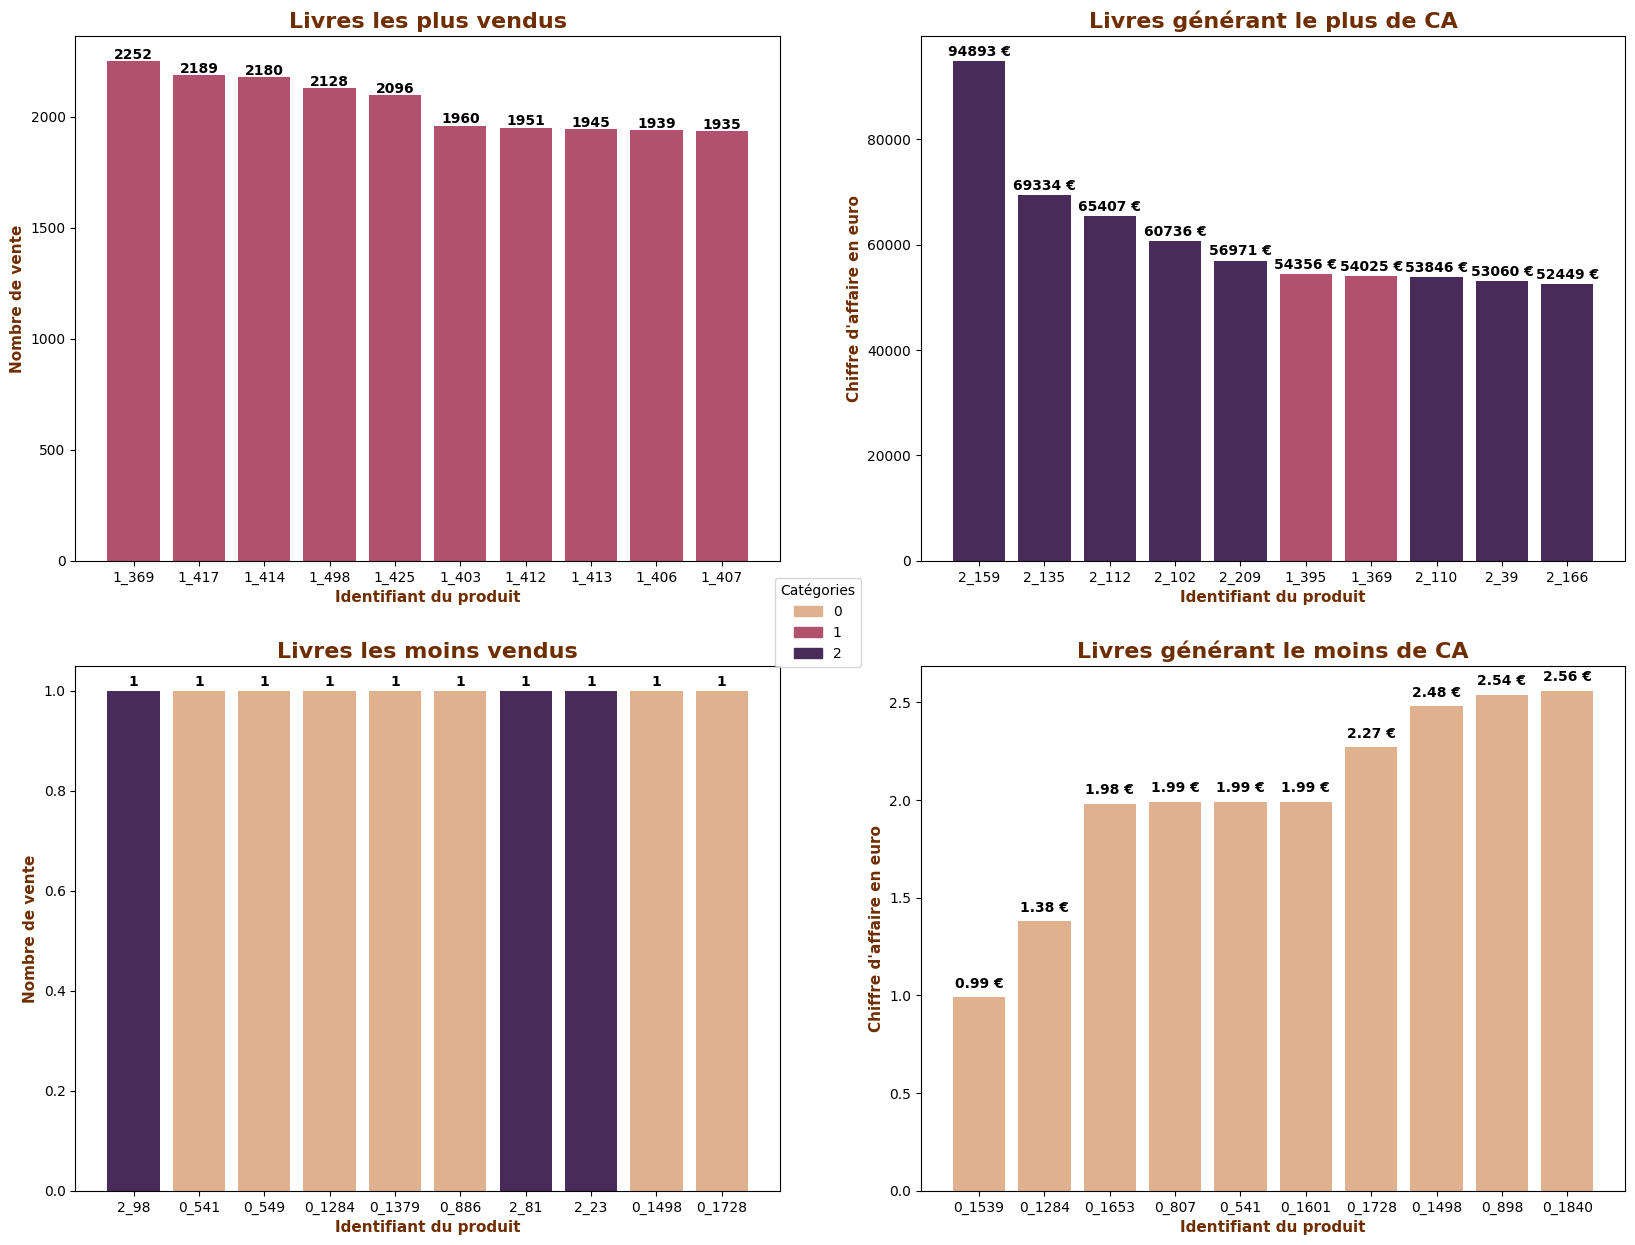

In [74]:
#Produit les plus vendus
df_top_ventes = df_detail_transactions[["product_id", "category"]].value_counts().reset_index(name="nb_ventes").sort_values(by="nb_ventes", ascending=False).head(10)

#Produit les moins vendus
df_flop_ventes = df_detail_transactions[["product_id", "category"]].value_counts().reset_index(name="nb_ventes").sort_values(by="nb_ventes", ascending=True).head(10)

#Produits générant le plus de CA
df_top_turnover_by_product = df_detail_transactions.groupby(["product_id", "category"])["price"].sum().reset_index(name="turnover").sort_values(by="turnover", ascending=False).head(10)

#Produits générant le moins de CA
df_flop_turnover_by_product = df_detail_transactions.groupby(["product_id", "category"])["price"].sum().reset_index(name="turnover").sort_values(by="turnover", ascending=True).head(10)

#Groupe de graphique contenant les produits les plus vendus et les moins vendus et les produits générant le plus de CA et le moins de CA
fig, axes = plt.subplots(2,2)
fig.set_size_inches(20, 15)

#--------------------------------------------------------------------------#
# Top des ventes
#--------------------------------------------------------------------------#

#La couleur de la barre dépend de la catégorie du produit
bar_colors = []
for category in df_top_ventes["category"]:
    if category == 0:
        bar_colors.append("#DFB18E")
    elif category == 1:
        bar_colors.append("#B1516E")
    else :
        bar_colors.append("#492B5A")

axes[0,0].bar(x=df_top_ventes["product_id"], height=df_top_ventes["nb_ventes"], color=bar_colors)

axes[0,0].set_title("Livres les plus vendus", fontsize=16, color="#6F2E00", weight="bold")
axes[0,0].set_xlabel("Identifiant du produit", fontsize=11, color="#6F2E00", weight="bold")
axes[0,0].set_ylabel("Nombre de vente", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_top_ventes["nb_ventes"]):
    axes[0,0].text(i, valeur + 10, valeur, ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Produits générant le plus de CA
#--------------------------------------------------------------------------#

#La couleur de la barre dépend de la catégorie du produit
bar_colors = []
for category in df_top_turnover_by_product["category"]:
    if category == 0:
        bar_colors.append("#DFB18E")
    elif category == 1:
        bar_colors.append("#B1516E")
    else :
        bar_colors.append("#492B5A")

axes[0,1].bar(x=df_top_turnover_by_product["product_id"], height=df_top_turnover_by_product["turnover"], color=bar_colors)

axes[0,1].set_title("Livres générant le plus de CA", fontsize=16, color="#6F2E00", weight="bold")
axes[0,1].set_xlabel("Identifiant du produit", fontsize=11, color="#6F2E00", weight="bold")
axes[0,1].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_top_turnover_by_product["turnover"]):
    axes[0,1].text(i, valeur + 1000, str(int(valeur)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Flop des ventes
#--------------------------------------------------------------------------#

#La couleur de la barre dépend de la catégorie du produit
bar_colors = []
for category in df_flop_ventes["category"]:
    if category == 0:
        bar_colors.append("#DFB18E")
    elif category == 1:
        bar_colors.append("#B1516E")
    else :
        bar_colors.append("#492B5A")

axes[1,0].bar(x= df_flop_ventes["product_id"], height=df_flop_ventes["nb_ventes"], color=bar_colors)

axes[1,0].set_title("Livres les moins vendus", fontsize=16, color="#6F2E00", weight="bold")
axes[1,0].set_xlabel("Identifiant du produit", fontsize=11, color="#6F2E00", weight="bold")
axes[1,0].set_ylabel("Nombre de vente", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_flop_ventes["nb_ventes"]):
    axes[1,0].text(i, valeur +0.01, valeur, ha="center", weight="bold")


#--------------------------------------------------------------------------#
# Produits générant le moins de CA
#--------------------------------------------------------------------------#

#La couleur de la barre dépend de la catégorie du produit
bar_colors = []
for category in df_flop_turnover_by_product["category"]:
    if category == 0:
        bar_colors.append("#DFB18E")
    elif category == 1:
        bar_colors.append("#B1516E")
    else :
        bar_colors.append("#492B5A")

axes[1,1].bar(x=df_flop_turnover_by_product["product_id"], height=df_flop_turnover_by_product["turnover"], color= bar_colors)

axes[1,1].set_title("Livres générant le moins de CA", fontsize=16, color="#6F2E00", weight="bold")
axes[1,1].set_xlabel("Identifiant du produit", fontsize=11, color="#6F2E00", weight="bold")
axes[1,1].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_flop_turnover_by_product["turnover"]):
    axes[1,1].text(i, valeur + 0.05, str(valeur) + " €", ha="center", weight="bold")

#Construction de la légende
handles = []
for category  in df_detail_transactions["category"].unique():
    if category == 0:
        handles.append( mpatches.Patch(color="#DFB18E", label=0))
    elif category == 1:
        handles.append( mpatches.Patch(color="#B1516E", label=1))
    else :
        handles.append( mpatches.Patch(color="#492B5A", label=2))

fig.legend(handles=handles, title="Catégories", loc="center")

plt.show()

<div style="background-color: RGB(160,111,119);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Informations clients</h2>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etapes 6.1 - Répartition du CA par client</h3>
</div>

In [75]:
#Dataframe contenant le chiffre d'affaire par client
df_turnover_by_client = df_detail_transactions.groupby("client_id")["price"].sum().reset_index(name="turnover")
df_turnover_by_client.head()


,client_id,turnover
0,c_1,558.18
1,c_10,1353.60
2,c_100,254.85
3,c_1000,2261.89
4,c_1001,1812.86


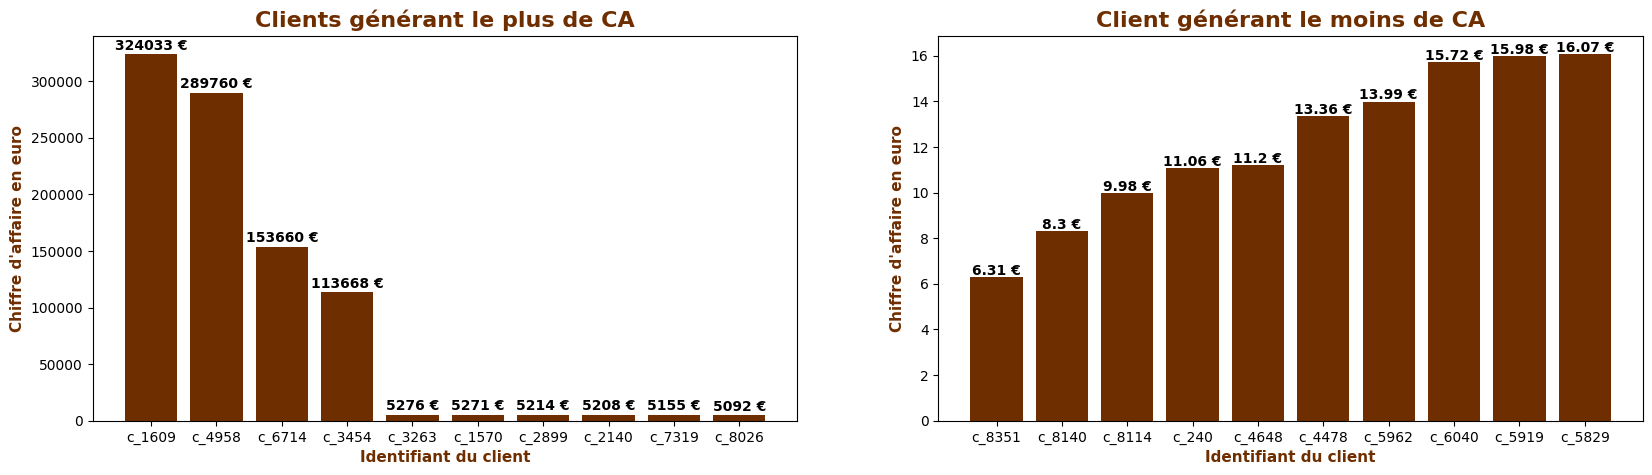

In [76]:
#Clients générant le plus de CA
df_top_clients = df_turnover_by_client.sort_values(by="turnover", ascending=False).head(10)

#Client générant le moins de CA
df_flop_clients = df_turnover_by_client.sort_values(by="turnover", ascending=True).head(10)

#Groupe de graphique contenant les produits les plus vendus et les moins vendus et les produits générant le plus de CA et le moins de CA
fig, axes = plt.subplots(1,2)
fig.set_size_inches(20, 5)

#--------------------------------------------------------------------------#
# Top des clients
#--------------------------------------------------------------------------#

axes[0].bar(x=df_top_clients["client_id"], height=df_top_clients["turnover"], color="#6F2E00")

axes[0].set_title("Clients générant le plus de CA", fontsize=16, color="#6F2E00", weight="bold")
axes[0].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_top_clients["turnover"]):
    axes[0].text(i, valeur + 4000, str(int(valeur)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Flop des clients
#--------------------------------------------------------------------------#

axes[1].bar(x= df_flop_clients["client_id"], height=df_flop_clients["turnover"], color="#6F2E00")

axes[1].set_title("Client générant le moins de CA", fontsize=16, color="#6F2E00", weight="bold")
axes[1].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_flop_clients["turnover"]):
    axes[1].text(i, valeur + 0.1, str(valeur) + " €", ha="center", weight="bold")

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
On constate que 4 clients génèrent une grande part du CA on peut eu conclure que ces clients sont de type <b>B2B</b>
</p>
</div>

In [77]:
#Liste des clients générant des CA les plus élevés
client_b2b_list=['c_1609','c_4958','c_6714','c_3454']

#CA des clients générant des CA moyens 
df_turnover_by_client_b2c = df_turnover_by_client[~df_turnover_by_client['client_id'].isin(client_b2b_list)]

#CA des clients générant les CA les plus élevés
df_turnover_by_client_b2b = df_turnover_by_client[df_turnover_by_client['client_id'].isin(client_b2b_list)]


#CA des clients générant le CA les plus élevés
ca_top_client = df_turnover_by_client_b2b["turnover"].sum()

print("Chiffre d'affaire des clients B2B est de {:,.2f} € ce qui représentent {:.2%} du CA total".format(ca_top_client, ca_top_client / ca_total))

Chiffre d'affaire des clients B2B est de 881,123.42 € ce qui représentent 7.43% du CA total


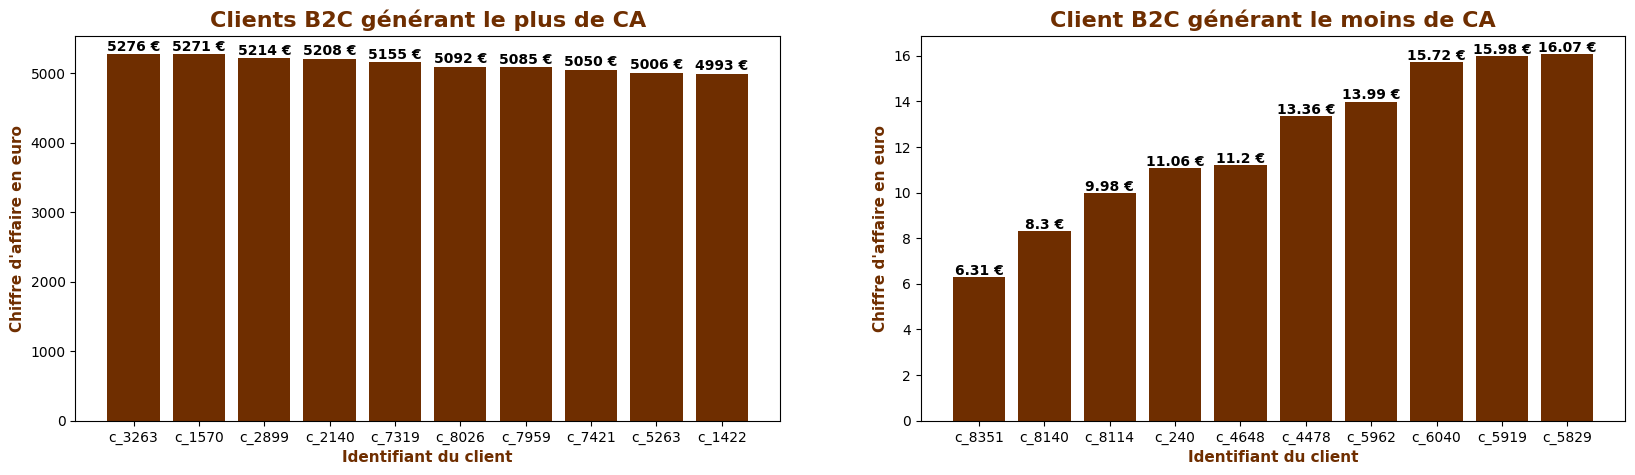

In [78]:
#Clients générant le plus de CA
df_top_clients_b2c = df_turnover_by_client_b2c.sort_values(by="turnover", ascending=False).head(10)

#Client générant le moins de CA
df_flop_clients_b2c = df_turnover_by_client_b2c.sort_values(by="turnover", ascending=True).head(10)

#Groupe de graphique contenant les produits les plus vendus et les moins vendus et les produits générant le plus de CA et le moins de CA
fig, axes = plt.subplots(1,2)
fig.set_size_inches(20, 5)

#--------------------------------------------------------------------------#
# Top des clients
#--------------------------------------------------------------------------#

axes[0].bar(x=df_top_clients_b2c["client_id"], height=df_top_clients_b2c["turnover"], color="#6F2E00")

axes[0].set_title("Clients B2C générant le plus de CA", fontsize=16, color="#6F2E00", weight="bold")
axes[0].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_top_clients_b2c["turnover"]):
    axes[0].text(i, valeur + 50, str(int(valeur)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Flop des clients
#--------------------------------------------------------------------------#

axes[1].bar(x= df_flop_clients_b2c["client_id"], height=df_flop_clients_b2c["turnover"], color="#6F2E00")

axes[1].set_title("Client B2C générant le moins de CA", fontsize=16, color="#6F2E00", weight="bold")
axes[1].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_flop_clients_b2c["turnover"]):
    axes[1].text(i, valeur + 0.1, str(valeur) + " €", ha="center", weight="bold")

plt.show()

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etapes 6.2 - Courbe de Lorenz</h3>
</div>

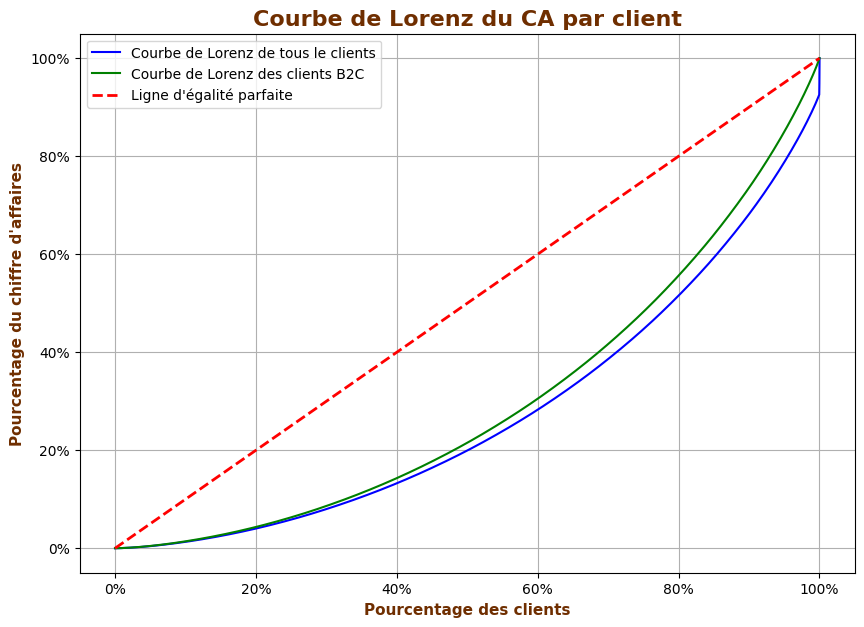

In [79]:
#Courbe de Lorenz

fig, axes = plt.subplots(1)
fig.set_size_inches(10, 7)

#Courbe de Lorenz de tous les clients
turnover_list = df_turnover_by_client["turnover"].values
nb_turnover = len(turnover_list)
lorenz = np.cumsum(np.sort(turnover_list)) / turnover_list.sum()

# La courbe de Lorenz commence à 0
lorenz = np.append([0],lorenz) 

#Il y a un segment de taille nb_turnover pour chaque individu, plus 1 segment supplémentaire d'ordonnée 0. Le premier segment commence à 0-1/nb_turnover, et le dernier termine à 1+1/nb_turnover.
xaxis = np.linspace(0-1/nb_turnover,1+1/nb_turnover,nb_turnover+1) 


axes.plot(xaxis, lorenz, color="blue", label="Courbe de Lorenz de tous le clients")
axes.grid(True)
axes.set_title("Courbe de Lorenz du CA par client", fontsize=16, color="#6F2E00", weight="bold")
axes.set_xlabel("Pourcentage des clients", fontsize=11, color="#6F2E00", weight="bold")
axes.set_ylabel("Pourcentage du chiffre d'affaires", fontsize=11, color="#6F2E00", weight="bold")

#Courbe de Lorenz des clients B2C
turnover_b2c_list = df_turnover_by_client_b2c["turnover"].values
nb_turnover_b2c = len(turnover_b2c_list)
lorenz_b2c = np.cumsum(np.sort(turnover_b2c_list)) / turnover_b2c_list.sum()

# La courbe de Lorenz commence à 0
lorenz_b2c = np.append([0],lorenz_b2c) 

#Il y a un segment de taille nb_turnover_b2c pour chaque individu, plus 1 segment supplémentaire d'ordonnée 0. Le premier segment commence à 0-1/nb_turnover_b2c, et le dernier termine à 1+1/nb_turnover_b2c.
xaxis = np.linspace(0-1/nb_turnover_b2c,1+1/nb_turnover_b2c,nb_turnover_b2c+1) 


axes.plot(xaxis, lorenz_b2c, color="green", label="Courbe de Lorenz des clients B2C")
axes.grid(True)
axes.set_title("Courbe de Lorenz du CA par client", fontsize=16, color="#6F2E00", weight="bold")
axes.set_xlabel("Pourcentage des clients", fontsize=11, color="#6F2E00", weight="bold")
axes.set_ylabel("Pourcentage du chiffre d'affaires", fontsize=11, color="#6F2E00", weight="bold")

axes.xaxis.set_major_formatter(ticker.PercentFormatter(1))
axes.yaxis.set_major_formatter(ticker.PercentFormatter(1))

plt.plot([0, 1], [0, 1], label="Ligne d'égalité parfaite", color="red", linestyle="--", linewidth=2)

axes.legend(loc="upper left")

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
<b>50 %</b> des clients génèrent <b>20 %</b> du CA
<br />
Quelques client ont des CA supérieures à l'ensemble des autres clients. Ce sont des clients B2B
</p>
</div>

In [80]:
#Calcul de l"indice de gini

 # Surface sous la courbe de Lorenz. Le premier segment (lorenz[0]) est à moitié en dessous de 0, on le coupe donc en 2, on fait de même pour le dernier segment lorenz[-1] qui est à moitié au dessus de 1.
AUC = (lorenz.sum() -lorenz[-1]/2 -lorenz[0]/2)/nb_turnover
S = 0.5 - AUC # surface entre la première bissectrice et le courbe de Lorenz
gini = 2*S

AUC_b2c = (lorenz_b2c.sum() -lorenz[-1]/2 -lorenz[0]/2)/nb_turnover
S = 0.5 - AUC_b2c 
gini_b2c = 2*S

print("L'indice de gini du CA de tous les clients est de {:.3}".format(gini))
print("L'indice de gini du CA des clients B2C {:.3}".format(gini_b2c))

L'indice de gini du CA de tous les clients est de 0.446
L'indice de gini du CA des clients B2C 0.403


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
L'indice de gini du CA par client est de <b>0.44</b> donc une minorité de client génèrent un chiffre d'affaire élevé
</p>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etapes 6.3 - Etude des clients</h3>
</div>

In [81]:
#Dataframe contenant le chiffre d'affaire par client
df_turnover_by_client = df_detail_transactions.groupby("client_id")["price"].sum().reset_index(name="turnover")

#Dataframe contenant le nombre de produit par transaction et par tranche d'age
df_nb_product_by_transaction_and_age = df_detail_transactions[["client_id", "session_id"]].value_counts().reset_index()

#Nombre de transaction par client
df_nb_transaction_by_client = df_nb_product_by_transaction_and_age["client_id"].value_counts().reset_index(name = "nb_transaction")

#Nombre de produit acheté par transaction et par client
df_nb_product_by_client_and_session = df_detail_transactions.groupby("client_id")["session_id"].value_counts().reset_index(name="nb_sales_product")

#Nombre d'article  commandés en moyenne par client
df_nb_average_product_by_client = df_nb_product_by_client_and_session.groupby(["client_id"])["nb_sales_product"].mean().reset_index(name="nb_average_product")

#Montant du panier par client et session
df_amount_by_client_and_session = df_detail_transactions.groupby(["client_id","session_id"])["price"].sum().reset_index(name="turnover")

#Montant du panier moyen par client
df_average_basket_by_client = df_amount_by_client_and_session.groupby(["client_id"])["turnover"].mean().reset_index(name="average_basket")

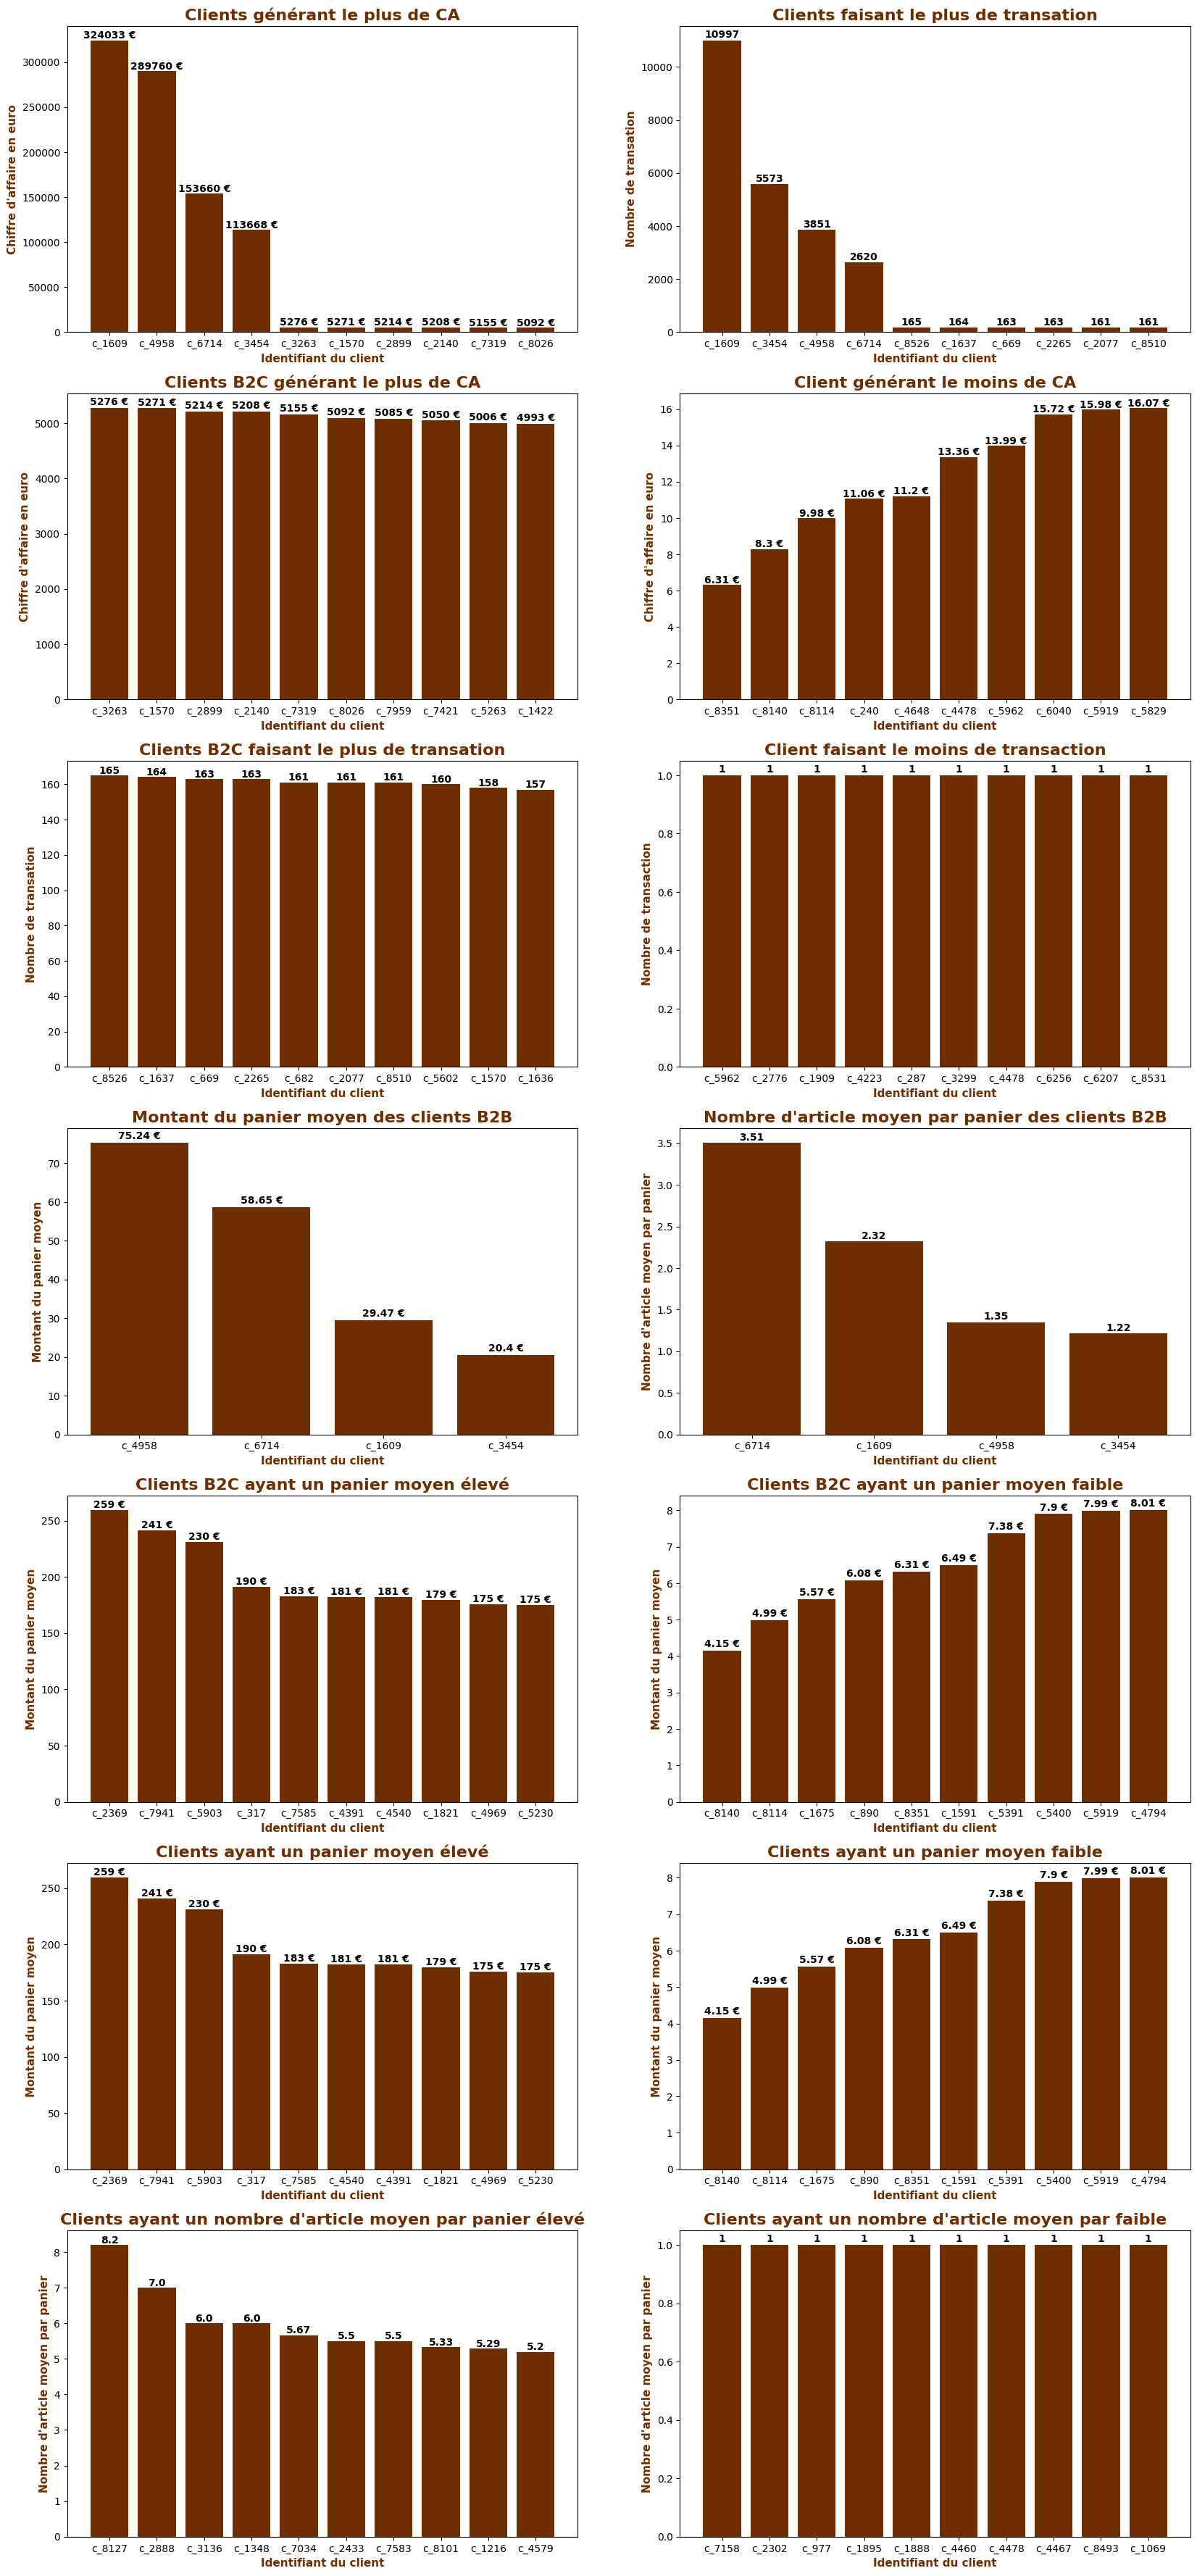

In [82]:
#Clients générant le plus de CA
df_top_clients = df_turnover_by_client.sort_values(by="turnover", ascending=False).head(10)

#Clients générant le moins de CA
df_flop_clients = df_turnover_by_client.sort_values(by="turnover", ascending=True).head(10)

#Clients ayant effecuté le plus de transaction
df_top_clients_transaction = df_nb_transaction_by_client.sort_values(by="nb_transaction", ascending=False).head(10)

#Clients B2C ayant effectué le plus de transaction
df_top_clients_b2c_transaction = df_nb_transaction_by_client[~df_nb_transaction_by_client['client_id'].isin(client_b2b_list)].sort_values(by="nb_transaction", ascending=False).head(10)

#Clients ayant effecuté le moins de transaction
df_flop_clients_transaction = df_nb_transaction_by_client.sort_values(by="nb_transaction", ascending=True).head(10)

#Clients ayant le panier moyen le plus élevé
df_top_clients_average_basket = df_average_basket_by_client.sort_values(by="average_basket", ascending=False).head(10)

#Clients ayant le panier moyen le moins élevé
df_flop_clients_average_basket = df_average_basket_by_client.sort_values(by="average_basket", ascending=True).head(10)

#Clients B2C ayant le panier moyen le plus élevé
df_top_clients_b2c_average_basket = df_average_basket_by_client[~df_average_basket_by_client['client_id'].isin(client_b2b_list)].sort_values(by="average_basket", ascending=False).head(10)

#Clients B2C ayant le panier moyen le moins élevé
df_flop_clients_b2c_average_basket = df_average_basket_by_client[~df_average_basket_by_client['client_id'].isin(client_b2b_list)].sort_values(by="average_basket", ascending=True).head(10)

#Montant du panier moyen des clients B2B
df_clients_b2b_average_basket = df_average_basket_by_client[df_average_basket_by_client['client_id'].isin(client_b2b_list)].sort_values(by="average_basket", ascending=False)

#Clients ayant la moyenne d'article au panier le plus élevée
df_top_clients_average_nb_products = df_nb_average_product_by_client.sort_values(by="nb_average_product", ascending=False).head(10)

#Clients ayant la moyenne d'article au panier le moins élevée
df_flop_clients_average_nb_products = df_nb_average_product_by_client.sort_values(by="nb_average_product", ascending=True).head(10)

#Nombre d'article moyen par panier des clients B2B
df_clients_b2b_average_nb_products = df_nb_average_product_by_client[df_nb_average_product_by_client['client_id'].isin(client_b2b_list)].sort_values(by="nb_average_product", ascending=False)

#Groupe de graphique contenant les produits les plus vendus et les moins vendus et les produits générant le plus de CA et le moins de CA
fig, axes = plt.subplots(7,2)
fig.set_size_inches(20, 45)

#--------------------------------------------------------------------------#
# Clients générant le plus de CA
#--------------------------------------------------------------------------#

axes[0,0].bar(x=df_top_clients["client_id"], height=df_top_clients["turnover"], color="#6F2E00")

axes[0,0].set_title("Clients générant le plus de CA", fontsize=16, color="#6F2E00", weight="bold")
axes[0,0].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[0,0].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_top_clients["turnover"]):
    axes[0,0].text(i, valeur + 2000, str(int(valeur)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients faisant le plus de transation
#--------------------------------------------------------------------------#

axes[0,1].bar(x=df_top_clients_transaction["client_id"], height=df_top_clients_transaction["nb_transaction"], color="#6F2E00")

axes[0,1].set_title("Clients faisant le plus de transation", fontsize=16, color="#6F2E00", weight="bold")
axes[0,1].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[0,1].set_ylabel("Nombre de transation", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_top_clients_transaction["nb_transaction"]):
    axes[0,1].text(i, valeur + 100, valeur, ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients B2C générant le plus de CA
#--------------------------------------------------------------------------#
axes[1,0].bar(x=df_top_clients_b2c["client_id"], height=df_top_clients_b2c["turnover"], color="#6F2E00")

axes[1,0].set_title("Clients B2C générant le plus de CA", fontsize=16, color="#6F2E00", weight="bold")
axes[1,0].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[1,0].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_top_clients_b2c["turnover"]):
    axes[1,0].text(i, valeur + 50, str(int(valeur)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients générant le moins de CA
#--------------------------------------------------------------------------#

axes[1,1].bar(x= df_flop_clients["client_id"], height=df_flop_clients["turnover"], color="#6F2E00")

axes[1,1].set_title("Client générant le moins de CA", fontsize=16, color="#6F2E00", weight="bold")
axes[1,1].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[1,1].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_flop_clients["turnover"]):
    axes[1,1].text(i, valeur + 0.1, str(valeur) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients B2C faisant le plus de transation
#--------------------------------------------------------------------------#

axes[2,0].bar(x=df_top_clients_b2c_transaction["client_id"], height=df_top_clients_b2c_transaction["nb_transaction"], color="#6F2E00")

axes[2,0].set_title("Clients B2C faisant le plus de transation", fontsize=16, color="#6F2E00", weight="bold")
axes[2,0].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[2,0].set_ylabel("Nombre de transation", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_top_clients_b2c_transaction["nb_transaction"]):
    axes[2,0].text(i, valeur + 1, valeur, ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients faisant le moins de transation
#--------------------------------------------------------------------------#

axes[2,1].bar(x= df_flop_clients_transaction["client_id"], height=df_flop_clients_transaction["nb_transaction"], color="#6F2E00")

axes[2,1].set_title("Client faisant le moins de transaction", fontsize=16, color="#6F2E00", weight="bold")
axes[2,1].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[2,1].set_ylabel("Nombre de transaction", fontsize=11, color="#6F2E00", weight="bold")

#Ajout des labels sur les barres
for i, valeur in enumerate(df_flop_clients_transaction["nb_transaction"]):
    axes[2,1].text(i, valeur + 0.01, valeur, ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients ayant un panier moyen élevé
#--------------------------------------------------------------------------#

axes[5,0].bar(x=df_top_clients_average_basket["client_id"], height=df_top_clients_average_basket["average_basket"], color="#6F2E00")

axes[5,0].set_title("Clients ayant un panier moyen élevé", fontsize=16, color="#6F2E00", weight="bold")
axes[5,0].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[5,0].set_ylabel("Montant du panier moyen", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_top_clients_average_basket["average_basket"]):
    axes[5,0].text(i, valeur + 2, str(int(valeur)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients ayant un panier moyens faible
#--------------------------------------------------------------------------#

axes[5,1].bar(x= df_flop_clients_average_basket["client_id"], height=df_flop_clients_average_basket["average_basket"], color="#6F2E00")

axes[5,1].set_title("Clients ayant un panier moyen faible", fontsize=16, color="#6F2E00", weight="bold")
axes[5,1].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[5,1].set_ylabel("Montant du panier moyen", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_flop_clients_average_basket["average_basket"]):
    axes[5,1].text(i, valeur + 0.1, str(round(valeur,2)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients B2C ayant un panier moyen élevé
#--------------------------------------------------------------------------#

axes[4,0].bar(x=df_top_clients_b2c_average_basket["client_id"], height=df_top_clients_b2c_average_basket["average_basket"], color="#6F2E00")

axes[4,0].set_title("Clients B2C ayant un panier moyen élevé", fontsize=16, color="#6F2E00", weight="bold")
axes[4,0].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[4,0].set_ylabel("Montant du panier moyen", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_top_clients_b2c_average_basket["average_basket"]):
    axes[4,0].text(i, valeur + 2, str(int(valeur)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients B2C ayant un panier moyens faible
#--------------------------------------------------------------------------#

axes[4,1].bar(x= df_flop_clients_b2c_average_basket["client_id"], height=df_flop_clients_b2c_average_basket["average_basket"], color="#6F2E00")

axes[4,1].set_title("Clients B2C ayant un panier moyen faible", fontsize=16, color="#6F2E00", weight="bold")
axes[4,1].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[4,1].set_ylabel("Montant du panier moyen", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_flop_clients_b2c_average_basket["average_basket"]):
    axes[4,1].text(i, valeur + 0.1, str(round(valeur,2)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Montant du panier moyen des clients B2B
#--------------------------------------------------------------------------#

axes[3,0].bar(x= df_clients_b2b_average_basket["client_id"], height=df_clients_b2b_average_basket["average_basket"], color="#6F2E00")

axes[3,0].set_title("Montant du panier moyen des clients B2B", fontsize=16, color="#6F2E00", weight="bold")
axes[3,0].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[3,0].set_ylabel("Montant du panier moyen", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_clients_b2b_average_basket["average_basket"]):
    axes[3,0].text(i, valeur + 1, str(round(valeur,2)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Nombre d'article moyen par panier des clients B2B
#--------------------------------------------------------------------------#

axes[3,1].bar(x= df_clients_b2b_average_nb_products["client_id"], height=df_clients_b2b_average_nb_products["nb_average_product"], color="#6F2E00")

axes[3,1].set_title("Nombre d'article moyen par panier des clients B2B", fontsize=16, color="#6F2E00", weight="bold")
axes[3,1].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[3,1].set_ylabel("Nombre d'article moyen par panier", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_clients_b2b_average_nb_products["nb_average_product"]):
    axes[3,1].text(i, valeur + 0.03, round(valeur, 2), ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients B2C ayant une moyenne d'article au panier la plus élevée
#--------------------------------------------------------------------------#
axes[6,0].bar(x=df_top_clients_average_nb_products["client_id"], height=df_top_clients_average_nb_products["nb_average_product"], color="#6F2E00")

axes[6,0].set_title("Clients ayant un nombre d'article moyen par panier élevé", fontsize=16, color="#6F2E00", weight="bold")
axes[6,0].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[6,0].set_ylabel("Nombre d'article moyen par panier", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_top_clients_average_nb_products["nb_average_product"]):
    axes[6,0].text(i, valeur + 0.05, round(valeur,2), ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Clients ayant une moyenne d'article au panier la moins élevée
#--------------------------------------------------------------------------#
axes[6,1].bar(x=df_flop_clients_average_nb_products["client_id"], height=df_flop_clients_average_nb_products["nb_average_product"], color="#6F2E00")

axes[6,1].set_title("Clients ayant un nombre d'article moyen par faible", fontsize=16, color="#6F2E00", weight="bold")
axes[6,1].set_xlabel("Identifiant du client", fontsize=11, color="#6F2E00", weight="bold")
axes[6,1].set_ylabel("Nombre d'article moyen par panier", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_flop_clients_average_nb_products["nb_average_product"]):
    axes[6,1].text(i, valeur + 0.01, int(valeur), ha="center", weight="bold")

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Il y a 4 clients qui génèrent un CA plus élevé que les autres clients grâce aux nombre de transaction qu'ils effectuent
</p>
</div>

In [83]:
#Dataframe contenant les transactions des clients B2C
df_detail_transactions_b2c = df_detail_transactions[~df_detail_transactions['client_id'].isin(client_b2b_list)]

#Dataframe contenant les transactions des clients B2B
df_detail_transactions_b2b = df_detail_transactions[df_detail_transactions['client_id'].isin(client_b2b_list)]

<div style="background-color: RGB(160,111,119);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 7 - Jours et heures d'achat</h2>
</div>

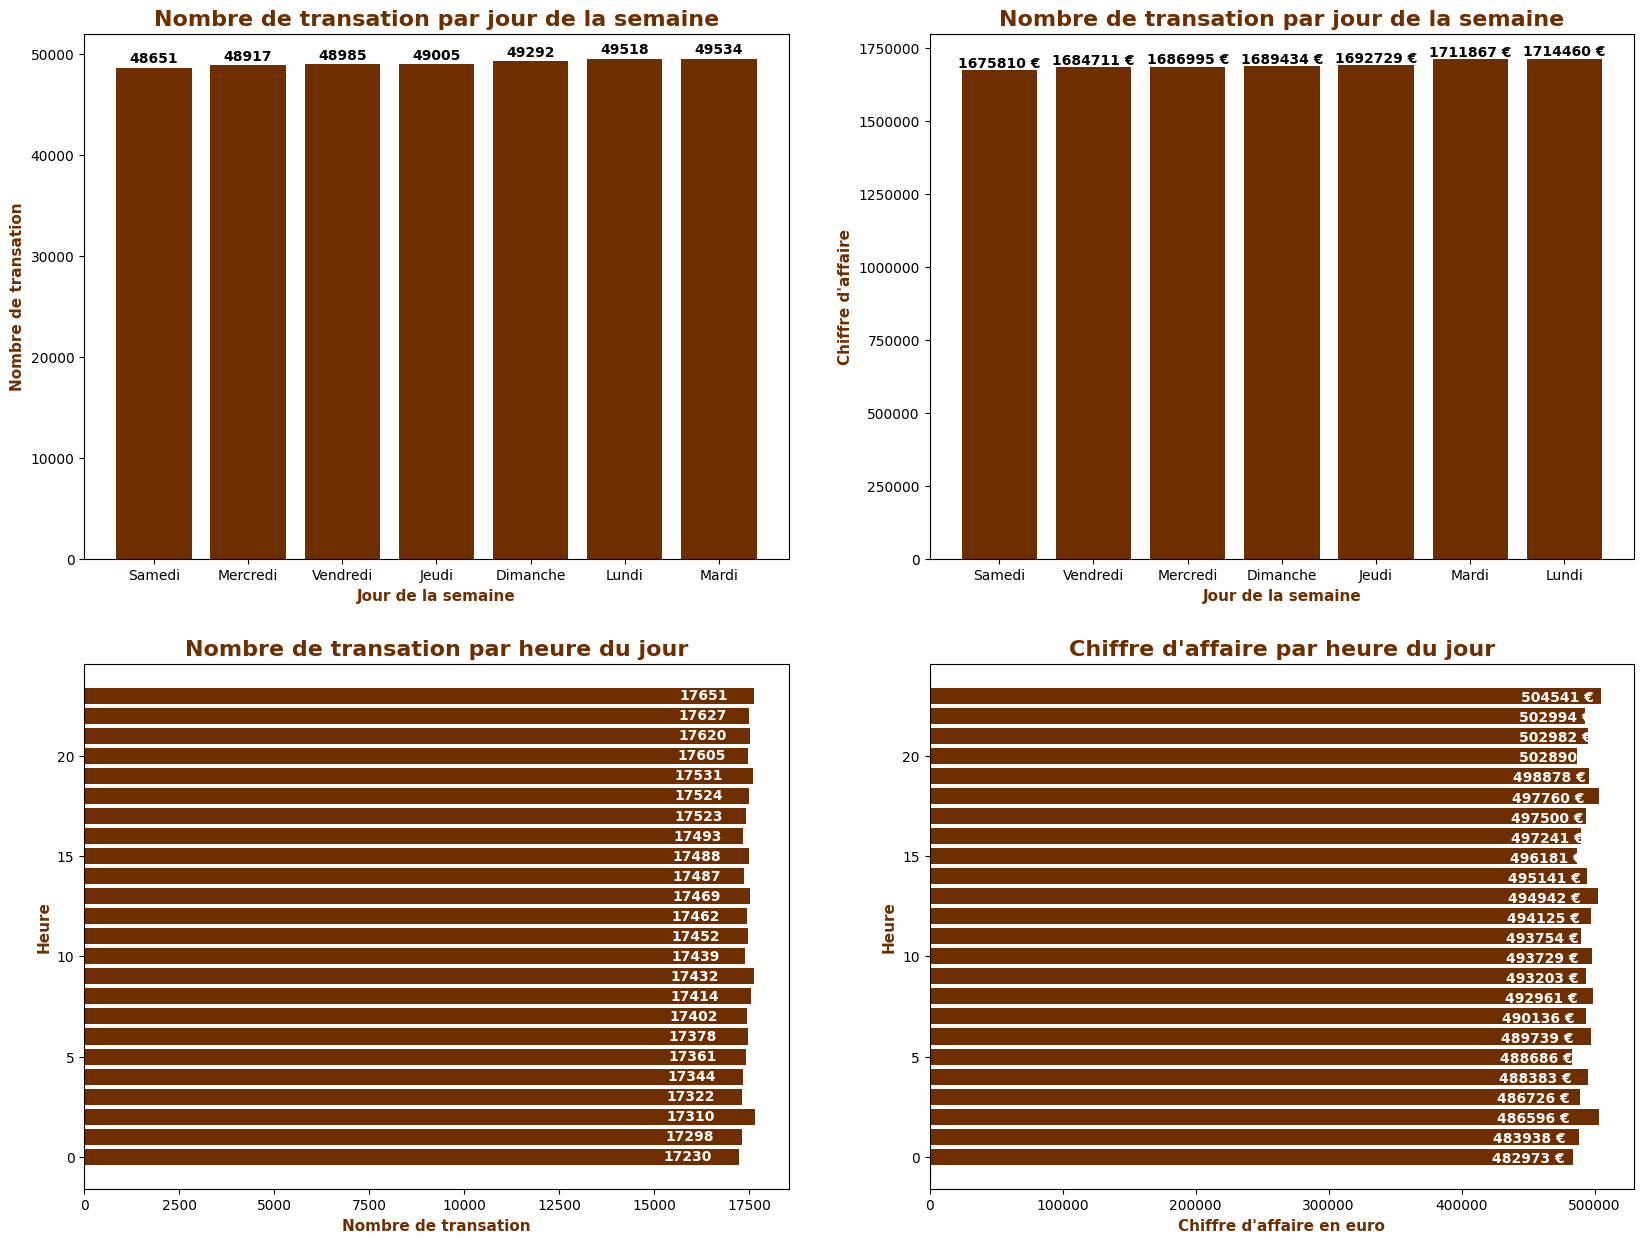

In [84]:
#Répartition des jours d'achat
df_repartition_day_transaction = df_detail_transactions.groupby("only_day_transaction").agg({"session_id": "nunique"}).rename(columns={"session_id": "nb_session"}).reset_index().sort_values("nb_session")

#Répartition des heures d'achat
df_repartition_hour_transaction = df_detail_transactions.groupby("hour_transaction").agg({"session_id": "nunique"}).rename(columns={"session_id": "nb_session"}).reset_index().sort_values("nb_session")

#Répartition du CA par jour
df_turnover_by_day = df_detail_transactions.groupby("only_day_transaction")["price"].sum().reset_index(name="turnover").sort_values("turnover")

#Répartition des heures d'achat
df_turnover_by_hour = df_detail_transactions.groupby("hour_transaction")["price"].sum().reset_index(name="turnover").sort_values("turnover")

#Groupe de graphique contenant les produits les plus vendus et les moins vendus et les produits générant le plus de CA et le moins de CA
fig, axes = plt.subplots(2,2)
fig.set_size_inches(20, 15)

#--------------------------------------------------------------------------#
# Nombre de transaction par jour
#--------------------------------------------------------------------------#
axes[0,0].bar(x=df_repartition_day_transaction["only_day_transaction"], height=df_repartition_day_transaction["nb_session"], color="#6F2E00")

axes[0,0].set_title("Nombre de transation par jour de la semaine", fontsize=16, color="#6F2E00", weight="bold")
axes[0,0].set_xlabel("Jour de la semaine", fontsize=11, color="#6F2E00", weight="bold")
axes[0,0].set_ylabel("Nombre de transation", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_repartition_day_transaction["nb_session"]):
    axes[0,0].text(i, valeur + 500, int(valeur), ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Chiffre d'affaire par jour
#--------------------------------------------------------------------------#
axes[0,1].bar(x=df_turnover_by_day["only_day_transaction"], height=df_turnover_by_day["turnover"], color="#6F2E00")

axes[0,1].set_title("Nombre de transation par jour de la semaine", fontsize=16, color="#6F2E00", weight="bold")
axes[0,1].set_xlabel("Jour de la semaine", fontsize=11, color="#6F2E00", weight="bold")
axes[0,1].set_ylabel("Chiffre d'affaire", fontsize=11, color="#6F2E00", weight="bold")

#Format de l'axe des ordonnés
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
axes[0,1].yaxis.set_major_formatter(formatter)

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_turnover_by_day["turnover"]):
    axes[0,1].text(i, valeur + 10000, str(int(valeur)) + " €", ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Nombre de transaction par heure
#--------------------------------------------------------------------------#
axes[1,0].barh(y=df_repartition_hour_transaction["hour_transaction"], width=df_repartition_hour_transaction["nb_session"], color="#6F2E00")

axes[1,0].set_title("Nombre de transation par heure du jour", fontsize=16, color="#6F2E00", weight="bold")
axes[1,0].set_xlabel("Nombre de transation", fontsize=11, color="#6F2E00", weight="bold")
axes[1,0].set_ylabel("Heure", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_repartition_hour_transaction["nb_session"]):
    axes[1,0].text(valeur - 2000, i - 0.2, int(valeur), ha="left", weight="bold", color="white")



#--------------------------------------------------------------------------#
# Chiffre d'affaire par heure
#--------------------------------------------------------------------------#
axes[1,1].barh(y=df_turnover_by_hour["hour_transaction"], width=df_turnover_by_hour["turnover"], color="#6F2E00")

axes[1,1].set_title("Chiffre d'affaire par heure du jour", fontsize=16, color="#6F2E00", weight="bold")
axes[1,1].set_xlabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")
axes[1,1].set_ylabel("Heure", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_turnover_by_hour["turnover"]):
    axes[1,1].text(valeur - 60000, i -0.3, str(int(valeur)) + " €", weight="bold", color="white")

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Les clients à toutes heure de la journée et tous les jours de la semaines
</p>
</div>

<div style="background-color: RGB(160,111,119);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 8 - CA par âge, genre et catégorie</h2>
</div>

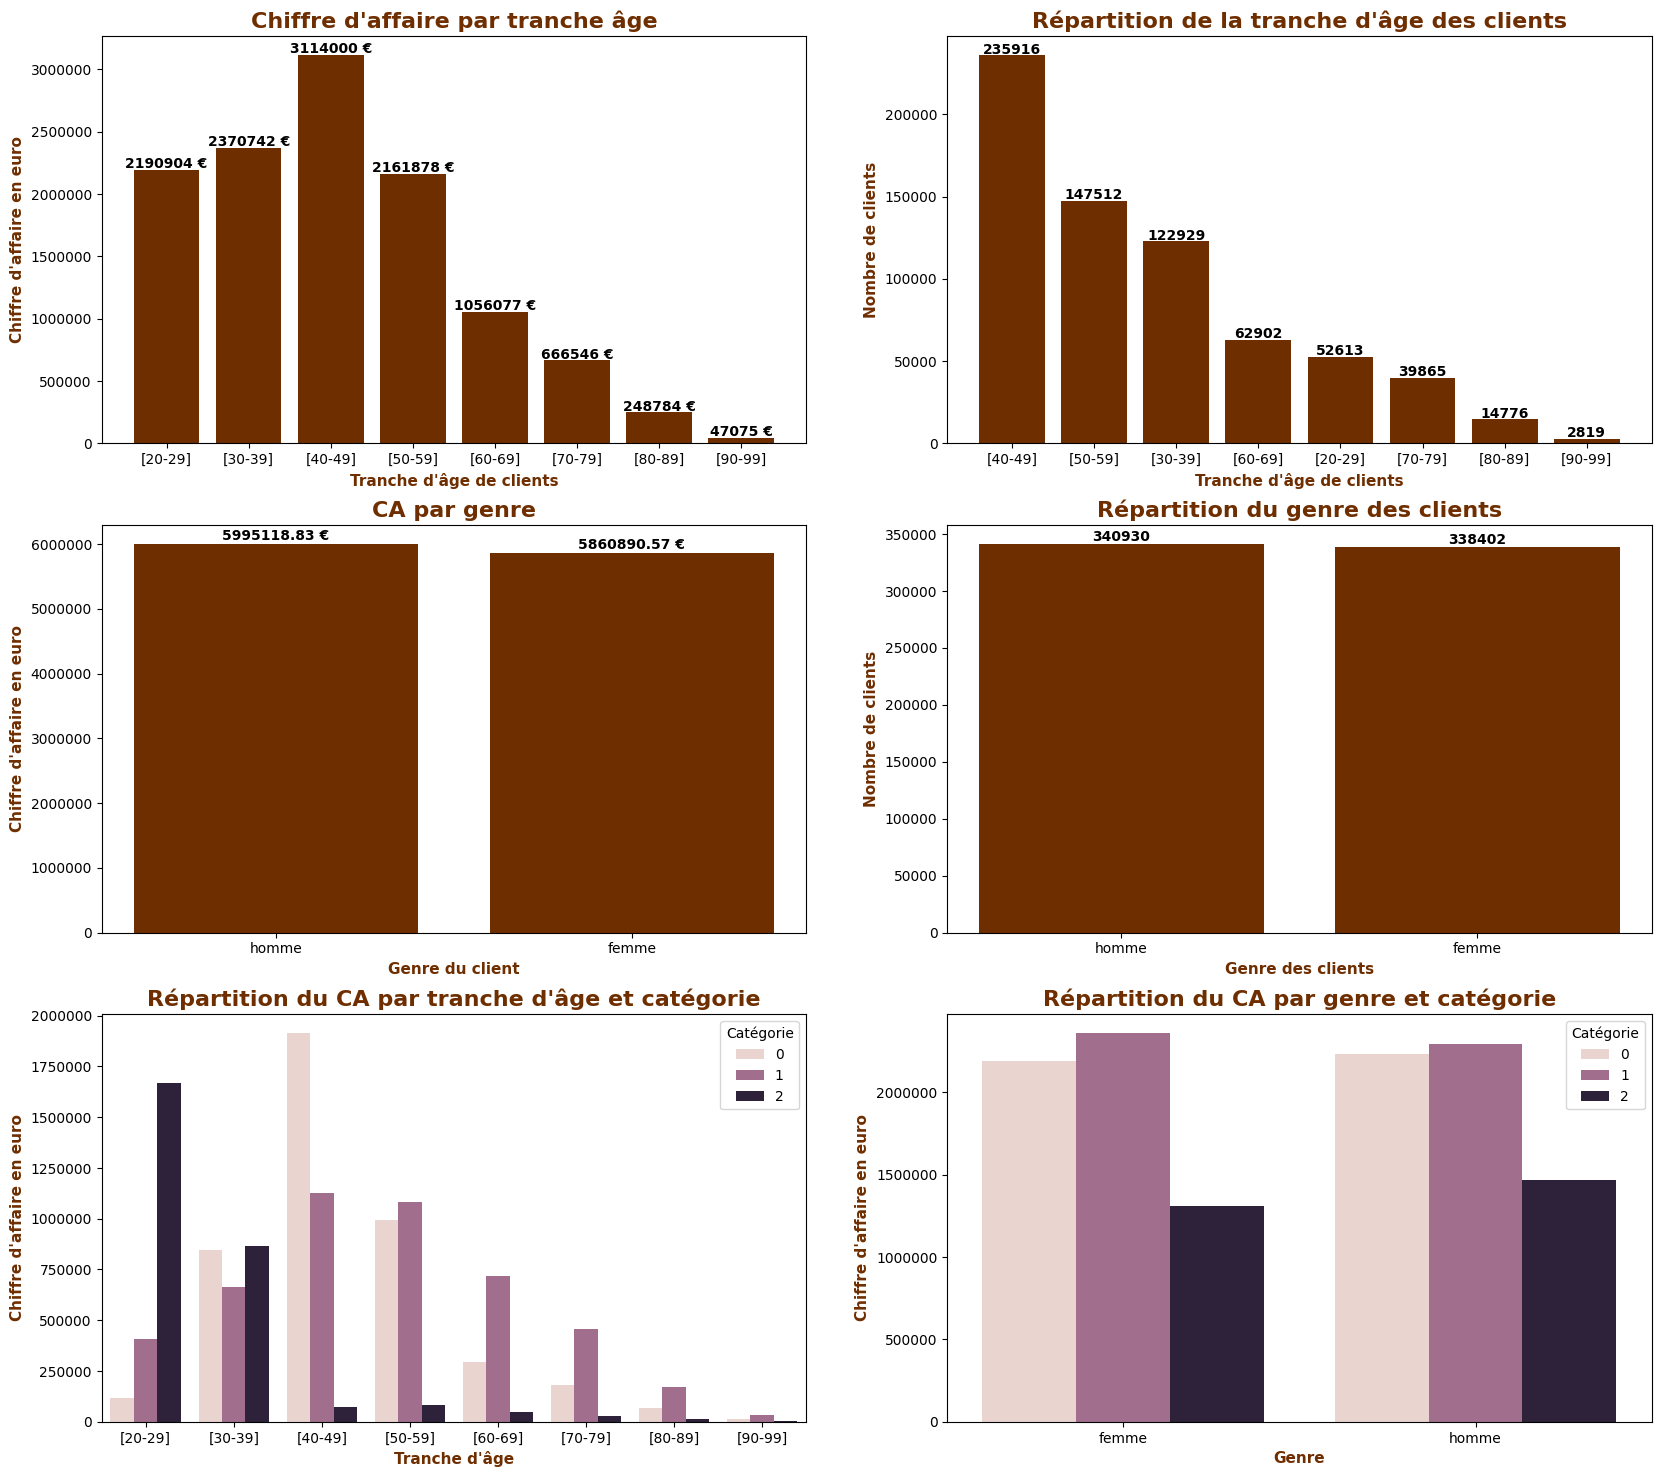

In [85]:
#CA par âge
df_turnover_by_age = df_detail_transactions.groupby("age_group")["price"].sum().reset_index(name="turnover")

#Nombre de client par tranche d'âge
df_nb_client_by_age = df_detail_transactions["age_group"].value_counts().reset_index(name="nb_client").sort_values(by="nb_client", ascending=False)

#CA par âge et catégorie
df_turnover_by_age_and_category = df_detail_transactions.groupby(["age_group", "category"])["price"].sum().reset_index(name="turnover")

#CA par genre
df_turnover_by_genre = df_detail_transactions.groupby("gender")["price"].sum().reset_index(name="turnover").sort_values(by="turnover", ascending=False)

#Nombre de client par genre
df_nb_client_by_gender = df_detail_transactions["gender"].value_counts().reset_index(name="nb_client").sort_values(by="nb_client", ascending=False)

#CA par genre et catégorie
df_turnover_by_genre_and_category = df_detail_transactions.groupby(["gender", "category"])["price"].sum().reset_index(name="turnover").sort_values(by="turnover", ascending=False)

#Groupe de graphique contenant les répartions des âges et genre des clients et les catégories selon l'âge et le genre des clients
fig, axes = plt.subplots(3,2)
fig.set_size_inches(20, 18)

#--------------------------------------------------------------------------#
# Chiffre d'affaire par tranche d'âge
#--------------------------------------------------------------------------#


axes[0,0].bar(x=df_turnover_by_age["age_group"], height=df_turnover_by_age["turnover"], color="#6F2E00")

axes[0,0].set_title("Chiffre d'affaire par tranche âge", fontsize=16, color="#6F2E00", weight="bold")
axes[0,0].set_xlabel("Tranche d'âge de clients", fontsize=11, color="#6F2E00", weight="bold")
axes[0,0].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_turnover_by_age["turnover"]):
    axes[0,0].text(i, valeur + 15000, str(int(valeur)) + " €", ha="center", weight="bold")

formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
axes[0,0].yaxis.set_major_formatter(formatter)

#--------------------------------------------------------------------------#
# Répartition des clients par tranche d'âge
#--------------------------------------------------------------------------#
axes[0,1].bar(x=df_nb_client_by_age["age_group"], height=df_nb_client_by_age["nb_client"], color="#6F2E00")

axes[0,1].set_title("Répartition de la tranche d'âge des clients", fontsize=16, color="#6F2E00", weight="bold")
axes[0,1].set_xlabel("Tranche d'âge de clients", fontsize=11, color="#6F2E00", weight="bold")
axes[0,1].set_ylabel("Nombre de clients", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_nb_client_by_age["nb_client"]):
    axes[0,1].text(i, valeur + 1000, valeur, ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Chiffre d'affaire par genre
#--------------------------------------------------------------------------#

axes[1,0].bar(x=df_turnover_by_genre["gender"], height=df_turnover_by_genre["turnover"], color="#6F2E00")

axes[1,0].set_title("CA par genre", fontsize=16, color="#6F2E00", weight="bold")
axes[1,0].set_xlabel("Genre du client", fontsize=11, color="#6F2E00", weight="bold")
axes[1,0].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_turnover_by_genre["turnover"]):
    axes[1,0].text(i, valeur + 70000, str(valeur) + " €", ha="center", weight="bold")

formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
axes[1,0].yaxis.set_major_formatter(formatter)

#--------------------------------------------------------------------------#
# Répartition des clients par genre
#--------------------------------------------------------------------------#
axes[1,1].bar(x=df_nb_client_by_gender["gender"], height=df_nb_client_by_gender["nb_client"], color="#6F2E00")

axes[1,1].set_title("Répartition du genre des clients", fontsize=16, color="#6F2E00", weight="bold")
axes[1,1].set_xlabel("Genre des clients", fontsize=11, color="#6F2E00", weight="bold")
axes[1,1].set_ylabel("Nombre de clients", fontsize=11, color="#6F2E00", weight="bold")

 #Ajout des labels sur les barres
for i, valeur in enumerate(df_nb_client_by_gender["nb_client"]):
    axes[1,1].text(i, valeur + 3000, valeur, ha="center", weight="bold")

#--------------------------------------------------------------------------#
# Chiffre d'affaire par genre et catégorie
#--------------------------------------------------------------------------#
sns.barplot(x='age_group', y='turnover', data=df_turnover_by_age_and_category, hue="category", ax=axes[2,0])
axes[2,0].set_title("Répartition du CA par tranche d'âge et catégorie", fontsize=16, color="#6F2E00", weight="bold")
axes[2,0].set_xlabel("Tranche d'âge", fontsize=11, color="#6F2E00", weight="bold")
axes[2,0].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")
axes[2,0].legend(title="Catégorie")

formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
axes[2,0].yaxis.set_major_formatter(formatter)

#--------------------------------------------------------------------------#
# Chiffre d'affaire par âge et catégorie
#--------------------------------------------------------------------------#
sns.barplot(x='gender', y='turnover', data=df_turnover_by_genre_and_category, hue="category", ax=axes[2,1])
axes[2,1].set_title("Répartition du CA par genre et catégorie", fontsize=16, color="#6F2E00", weight="bold")
axes[2,1].set_xlabel("Genre", fontsize=11, color="#6F2E00", weight="bold")
axes[2,1].set_ylabel("Chiffre d'affaire en euro", fontsize=11, color="#6F2E00", weight="bold")
axes[2,1].legend(title="Catégorie")

formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
axes[2,1].yaxis.set_major_formatter(formatter)

plt.show()


<div style="background-color: RGB(160,111,119);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 9 - Recherche de liens entre les données</h2>
</div>

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
La recherche de liens entre les données se fait avec les données des clients <b>B2C</b> car il n'y a que 4 clients <b>B2B</b> qui génèrent un CA bien supérieur aux autres clients
</p>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etapes 9.1 - Recherche d'un lien entre le genre des clients et les catégories de livre achetés</h3>
</div>

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
Le <b>genre</b> des clients et les <b>catégories</b> de livre achetés sont des variables <b>qualitatives</b>
<br />
Le <b>genre</b> est composé de 2 éléments et les <b>catégories</b> sont composés de 3 éléments donc le test de Chi-2 va être réalisé
<br />
Hypothèse H0 : Le genre du client est indépendant de la catégorie des livres achetés
<br />
Hypothèse H1 : Le genre du client dépend de la catégorie des livres achetés
</p>
</div>

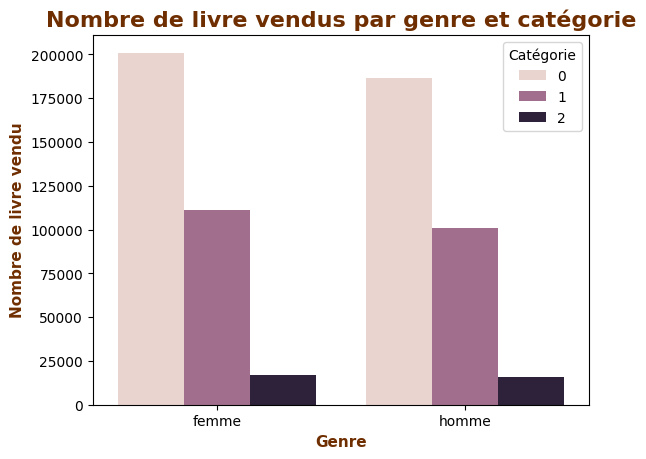

In [86]:
#Dataframme contenant le nombre de livre acheté par genre des clients et catégorie de livre achetés
df_nb_book_by_gender_and_category = df_detail_transactions_b2c[["gender","category"]].value_counts().reset_index(name="nb_book")

#Répartition des ventes de livres par genre de client et catégorie de livre
sns.barplot(data=df_nb_book_by_gender_and_category, x="gender", y="nb_book", hue="category")
plt.xlabel("Genre", fontsize=11, color="#6F2E00", weight="bold")
plt.ylabel("Nombre de livre vendu", fontsize=11, color="#6F2E00", weight="bold")
plt.title("Nombre de livre vendus par genre et catégorie", fontsize=16, color="#6F2E00", weight="bold")
plt.legend(title="Catégorie")
plt.show()

In [87]:
#Tableau de contingence du genre et des catégories
contingency_table = pd.crosstab(df_detail_transactions["category"], df_detail_transactions["gender"])

print("Tableau de contingence du genre et des catégories")
contingency_table

Tableau de contingence du genre et des catégories


gender,femme,homme
category,,
0,206220,209460
1,114899,112270
2,17283,19200


In [88]:
#Test du Chi-2

print("H0 : Les catégories de livres achetés par les clients ne dépendent pas de leur genre.")
print("H1 : Les catégories de livres achetés par les clients dépendent de leur genre.")
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Statistique Chi-2: {chi2_stat}")
print(f"Valeur p: {p_value}")
print(f"Degrés de liberté: {dof}")
print("Fréquences attendues:")
print(expected)

alpha = 0.05
if p_value > alpha:
    print("Les catégories de livres achetés par les clients ne dépendent pas de leur genre.(on ne rejette pas H0)")
else:
    print("Les catégories de livres achetés par les clients dépendent de leur genre. (on rejette H0)")

H0 : Les catégories de livres achetés par les clients ne dépendent pas de leur genre.
H1 : Les catégories de livres achetés par les clients dépendent de leur genre.
Statistique Chi-2: 147.00253568681114
Valeur p: 1.1989607410166063e-32
Degrés de liberté: 2
Fréquences attendues:
[[207066.56444861 208613.43555139]
 [113161.81769444 114007.18230556]
 [ 18173.61785695  18309.38214305]]
Les catégories de livres achetés par les clients dépendent de leur genre. (on rejette H0)


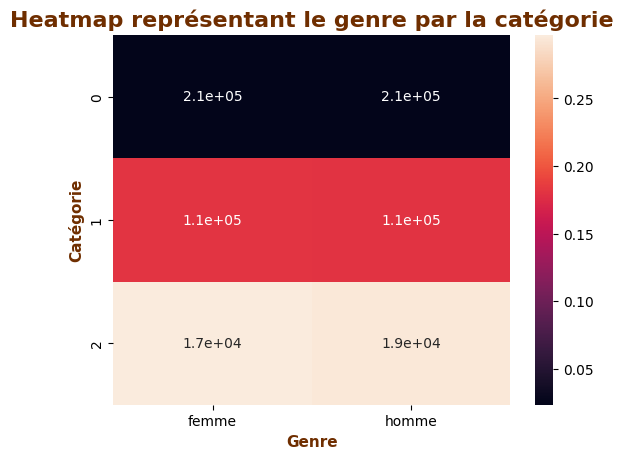

In [89]:
#Heatmap

measure = (contingency_table-expected)**2/expected
xi_n = measure.sum().sum()
table = measure/xi_n
sns.heatmap(table,annot=contingency_table)

plt.xlabel("Genre", fontsize=11, color="#6F2E00", weight="bold")
plt.ylabel("Catégorie", fontsize=11, color="#6F2E00", weight="bold")
plt.title("Heatmap représentant le genre par la catégorie", fontsize=16, color="#6F2E00", weight="bold")

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
<b>
Les catégories de livres achetés par les clients dépendent de leur genre
</b>
</p>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etapes 9.2 - Recherche d'un lien entre l'âge des clients et le montant total des achats</h3>
</div>

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
L'<b>âge</b> des clients et le <b>montant des achats</b> sont des variables <b>quantitatives</b> donc on vérifie si ces 2 variables suivent une distribution normale afin de savoir quel test appliquer sur ces données
 </p>
</div>

In [90]:
#Dataframe contenant le montant total des achat par client et age
df_turnover_by_client = df_detail_transactions_b2c.groupby(["client_id","age"])["price"].sum().reset_index(name="turnover")
print("Montant des achats par client")
df_turnover_by_client.head()

Montant des achats par client


,client_id,age,turnover
0,c_1,71,558.18
1,c_10,70,1353.60
2,c_100,34,254.85
3,c_1000,60,2261.89
4,c_1001,44,1812.86


[]

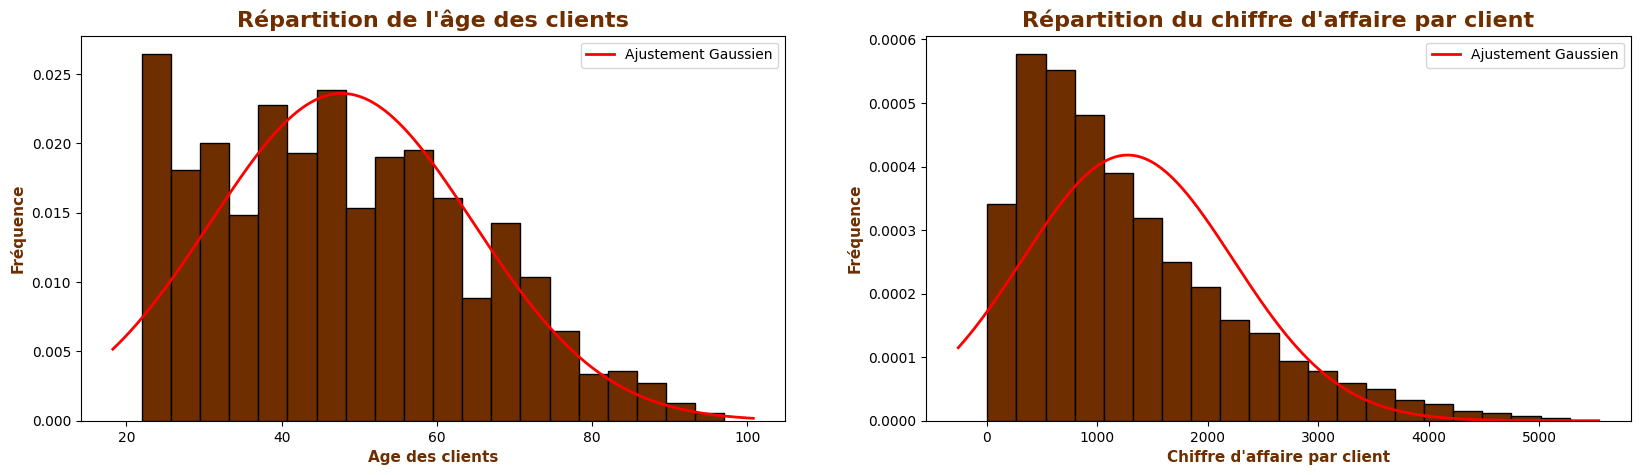

In [91]:
fig, axes = plt.subplots(1,2)
fig.set_size_inches(20,5)

#Distribution de l'âge des clients
axes[0].hist(df_turnover_by_client["age"], bins=20, density=True, color="#6F2E00", edgecolor='black')
axes[0].set_xlabel("Age des clients", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_ylabel("Fréquence", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_title("Répartition de l'âge des clients", fontsize=16, color="#6F2E00", weight="bold")

# Ajustement gaussien
mu, std = norm.fit(df_turnover_by_client["age"])
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, df_turnover_by_client["age"].count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
axes[0].plot(x, p, 'r', linewidth=2, label='Ajustement Gaussien')
axes[0].legend()

#Distribution du chiffre d'affaire par client
axes[1].hist(df_turnover_by_client["turnover"], bins=20, density=True, color="#6F2E00", edgecolor='black')
axes[1].set_xlabel("Chiffre d'affaire par client", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_ylabel("Fréquence", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_title("Répartition du chiffre d'affaire par client", fontsize=16, color="#6F2E00", weight="bold")

# Ajustement gaussien
mu, std = norm.fit(df_turnover_by_client["turnover"])
xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, df_turnover_by_client["turnover"].count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
axes[1].plot(x, p, 'r', linewidth=2, label='Ajustement Gaussien')
axes[1].legend()

plt.plot()

In [92]:
print("H0 : l'âge des clients suit une distribution normale")
print("H1 : l'âge des clients ne suit pas une distribution normale")

# Effectuer le test de Shapiro-Wilk
stat, p_value = shapiro(df_turnover_by_client["age"])

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("L'âge des clients suit une distribution normale (on ne rejette pas H0)")
else:
    print("L'âge des clients ne suit pas une distribution normale (on rejette H0)")

H0 : l'âge des clients suit une distribution normale
H1 : l'âge des clients ne suit pas une distribution normale
Statistique du test de Shapiro-Wilk : 0.9697306402580121
Valeur p : 4.615340399594916e-39
L'âge des clients ne suit pas une distribution normale (on rejette H0)


c:\Users\ndiem\anaconda3\envs\JEDHA\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


In [93]:
print("H0 : Le CA par client suit une distribution normale")
print("H1 : Le CA par client ne suit pas une distribution normale")

# Effectuer le test de Shapiro-Wilk
stat, p_value = shapiro(df_turnover_by_client["turnover"])

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Le CA par client suit une distribution normale (on ne rejette pas H0)")
else:
    print("Le CA par client ne suit pas une distribution normale (on rejette H0)")

H0 : Le CA par client suit une distribution normale
H1 : Le CA par client ne suit pas une distribution normale
Statistique du test de Shapiro-Wilk : 0.9036756283879576
Valeur p : 1.1266387813852006e-58
Le CA par client ne suit pas une distribution normale (on rejette H0)


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
L'<b>âge</b> des clients et le <b>montant des achats</b> sont des variables <b>quantitatives</b> et ne suivent pas une distribution normale donc le test de <b>Spearman</b> sera réalisé
</p>
</div>

Coefficient de corrélation de Spearman: -0.1851033025364363
Valeur p: 4.0190281387782426e-67
Il existe une correlation entre l'âge et le chiffre d'affaire


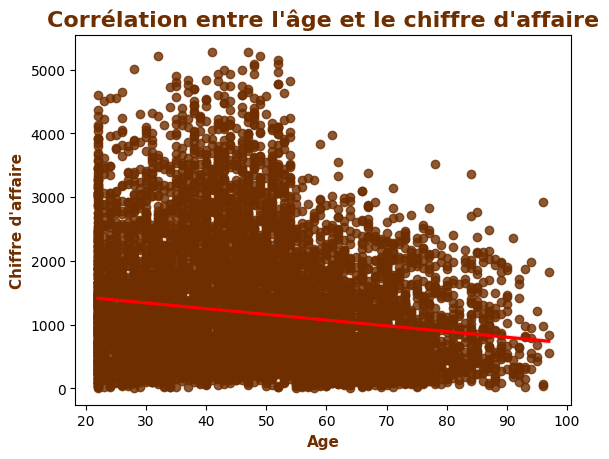

In [94]:
#Test de Spearman

# Visualisation de la tendance
sns.regplot(data=df_turnover_by_client, x="age", y="turnover", robust=True, line_kws=dict(color="r"), color="#6F2E00")

# Calculer le coefficient de corrélation de Spearman et la valeur p
spearman_corr, spearman_p_value = spearmanr(df_turnover_by_client["age"], df_turnover_by_client["turnover"])

plt.title("Corrélation entre l'âge et le chiffre d'affaire", fontsize=16, color="#6F2E00", weight="bold")
plt.xlabel("Age", fontsize=11, color="#6F2E00", weight="bold")
plt.ylabel("Chiffre d'affaire", fontsize=11, color="#6F2E00", weight="bold")

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

alpha = 0.05
if spearman_p_value > alpha:
    print("Il n'y a pas de correlation entre l'âge et le chiffre d'affaire")
else:
    print("Il existe une correlation entre l'âge et le chiffre d'affaire")

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
<b>L'âge est inversement correlé au chiffre d'affaire</b>
</p>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etapes 9.3 - Recherche d'un lien entre l'âge des clients et la fréquence d'achat</h3>
</div>

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
L'<b>âge</b> des clients et la <b>fréquence des achats</b> sont des variables <b>quantitatives</b> donc on vérifie si ces 2 variables suivent une distribution normale afin de savoir quel test appliquer sur ces données
 </p>
</div>

In [95]:
#Dataframe contenant le nombre de produit par transaction et par client
df_nb_product_by_transaction_and_client = df_detail_transactions_b2c[["client_id", "age", "session_id"]].value_counts().reset_index()

#Dataframe contenant la fréquence des transactions par client
df_purchase_frequency_by_client = df_nb_product_by_transaction_and_client[["client_id", "age"]].value_counts().reset_index(name = "purchase_frequency")

print("Fréquence des achats par client")
df_purchase_frequency_by_client.head()

Fréquence des achats par client


,client_id,age,purchase_frequency
0,c_8526,61,165
1,c_1637,38,164
2,c_669,38,163
3,c_2265,58,163
4,c_2077,42,161


[]

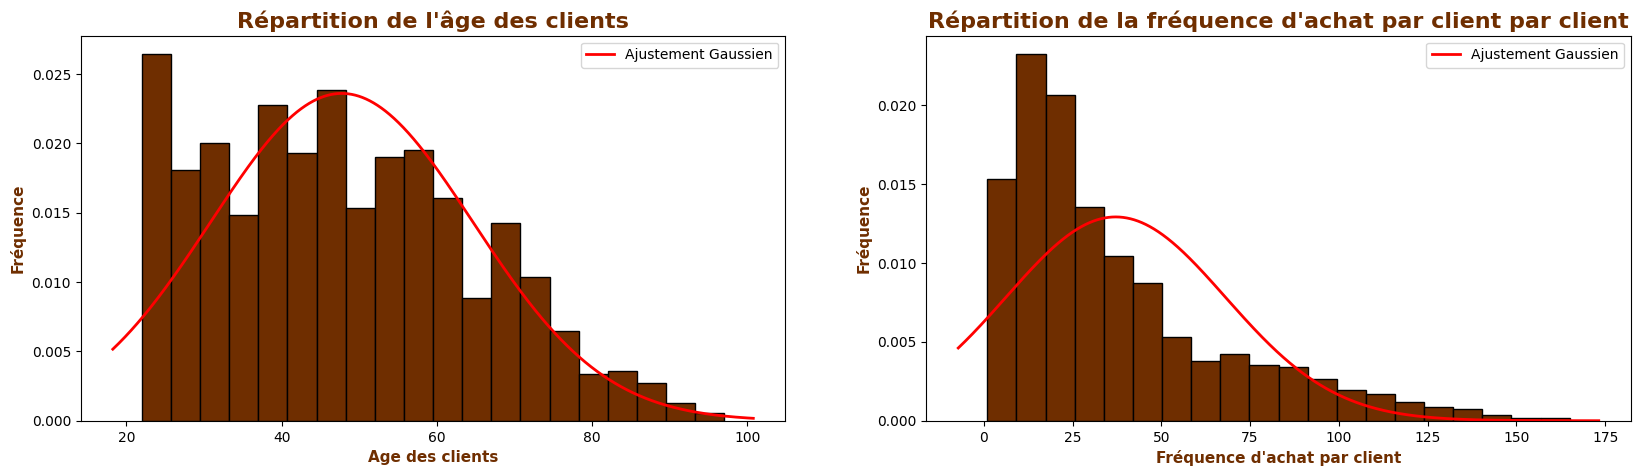

In [96]:
fig, axes = plt.subplots(1,2)
fig.set_size_inches(20,5)

#Distribution de l'âge des clients
axes[0].hist(df_purchase_frequency_by_client["age"], bins=20, density=True, color="#6F2E00", edgecolor='black')
axes[0].set_xlabel("Age des clients", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_ylabel("Fréquence", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_title("Répartition de l'âge des clients", fontsize=16, color="#6F2E00", weight="bold")

# Ajustement gaussien
mu, std = norm.fit(df_purchase_frequency_by_client["age"])
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, df_purchase_frequency_by_client["age"].count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
axes[0].plot(x, p, 'r', linewidth=2, label='Ajustement Gaussien')
axes[0].legend()

#Distribution de la fréquence d'achat par client
axes[1].hist(df_purchase_frequency_by_client["purchase_frequency"], bins=20, density=True, color="#6F2E00", edgecolor='black')
axes[1].set_xlabel("Fréquence d'achat par client", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_ylabel("Fréquence", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_title("Répartition de la fréquence d'achat par client par client", fontsize=16, color="#6F2E00", weight="bold")

# Ajustement gaussien
mu, std = norm.fit(df_purchase_frequency_by_client["purchase_frequency"])
xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, df_purchase_frequency_by_client["purchase_frequency"].count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
axes[1].plot(x, p, 'r', linewidth=2, label='Ajustement Gaussien')
axes[1].legend()

plt.plot()

In [97]:
print("H0 : l'âge des clients suit une distribution normale")
print("H1 : l'âge des clients ne suit pas une distribution normale")

# Effectuer le test de Shapiro-Wilk
stat, p_value = shapiro(df_purchase_frequency_by_client["age"])

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("L'âge des client suit une distribution normale (on ne rejette pas H0)")
else:
    print("L'âge des client ne suit pas une distribution normale (on rejette H0)")

H0 : l'âge des clients suit une distribution normale
H1 : l'âge des clients ne suit pas une distribution normale
Statistique du test de Shapiro-Wilk : 0.9697306402580368
Valeur p : 4.615340399726329e-39
L'âge des client ne suit pas une distribution normale (on rejette H0)


c:\Users\ndiem\anaconda3\envs\JEDHA\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


In [98]:
print("H0 : la fréquence d'achat suit une distribution normale")
print("H1 : la fréquence d'achat ne suit pas une distribution normale")

# Effectuer le test de Shapiro-Wilk
stat, p_value = shapiro(df_purchase_frequency_by_client["purchase_frequency"])

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("La fréquence d'achat suit une distribution normale (on ne rejette pas H0)")
else:
    print("La fréquence d'achat ne suit pas une distribution normale (on rejette H0)")

H0 : la fréquence d'achat suit une distribution normale
H1 : la fréquence d'achat ne suit pas une distribution normale
Statistique du test de Shapiro-Wilk : 0.8570852294959286
Valeur p : 2.668698869926381e-66
La fréquence d'achat ne suit pas une distribution normale (on rejette H0)


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
L'<b>âge</b> des clients et la <b>fréquence d'achat</b> des clients sont des variables <b>quantitatives</b> et ne suivent pas une distribution normale donc le test de <b>Spearman</b> sera réalisé
</p>
</div>

Coefficient de corrélation de Spearman: 0.21234739496458024
Valeur p: 3.180991037736119e-88
Il existe une correlation entre l'âge et la fréquence d'achat des clients


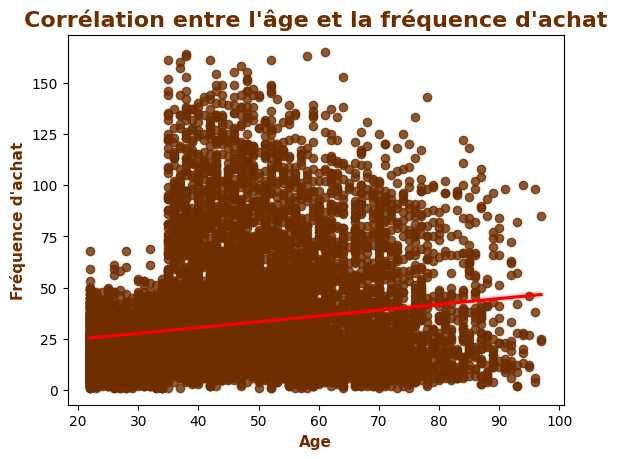

In [99]:
#Test de Spearman

# Visualisation de la tendance
sns.regplot(data=df_purchase_frequency_by_client, x="age", y="purchase_frequency", robust=True, line_kws=dict(color="r"), color="#6F2E00")

# Calculer le coefficient de corrélation de Spearman et la valeur p
spearman_corr, spearman_p_value = spearmanr(df_purchase_frequency_by_client["age"], df_purchase_frequency_by_client["purchase_frequency"])

plt.title("Corrélation entre l'âge et la fréquence d'achat", fontsize=16, color="#6F2E00", weight="bold")
plt.xlabel("Age", fontsize=11, color="#6F2E00", weight="bold")
plt.ylabel("Fréquence d'achat", fontsize=11, color="#6F2E00", weight="bold")

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

alpha = 0.05
if spearman_p_value > alpha:
    print("Il n'y a pas de correlation entre l'âge et la fréquence d'achat des clients")
else:
    print("Il existe une correlation entre l'âge et la fréquence d'achat des clients")

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
<b>L'âge est correlé à la fréquence des achats</b>
</p>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etapes 9.4 - Recherche d'un lien entre l'âge des clients et la taille du panier moyen</h3>
</div>

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
L'<b>âge</b> des clients et la <b>taille du panier moyen</b> sont des variables <b>quantitatives</b> donc on vérifie si ces 2 variables suivent une distribution normale afin de savoir quel test appliquer sur ces données
 </p>
</div>

In [100]:
#Dataframe contenant le montant des achats clients par session
df_turnover_by_client_and_transaction = df_detail_transactions_b2c.groupby(["client_id","age","session_id"])["price"].sum().reset_index(name="turnover")

#Dataframe contenant la moyenne des achat client par session
df_average_basket_by_client = df_turnover_by_client_and_transaction.groupby(["client_id","age"])["turnover"].mean().reset_index(name="average_basket")

print("Montant du panier moyen par client")
df_average_basket_by_client.head()

Montant du panier moyen par client


,client_id,age,average_basket
0,c_1,71,16.914545
1,c_10,70,39.811765
2,c_100,34,50.970000
3,c_1000,60,24.321398
4,c_1001,44,38.571489


[]

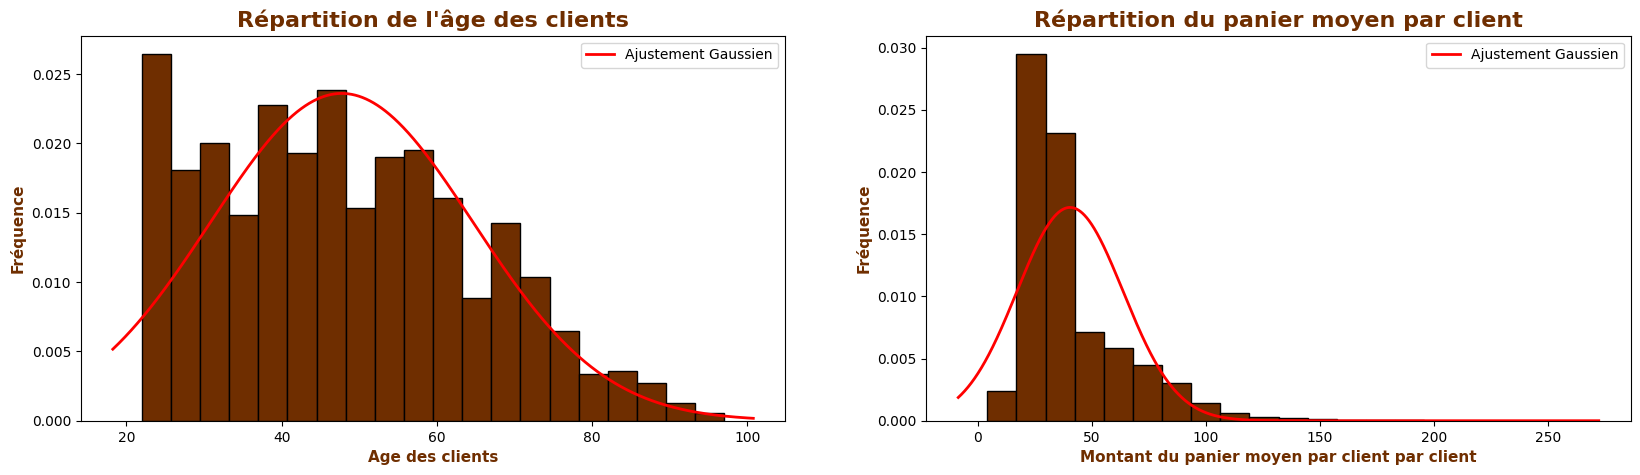

In [101]:
fig, axes = plt.subplots(1,2)
fig.set_size_inches(20,5)

#Distribution de l'âge des clients
axes[0].hist(df_average_basket_by_client["age"], bins=20, density=True, color="#6F2E00", edgecolor='black')
axes[0].set_xlabel("Age des clients", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_ylabel("Fréquence", fontsize=11, color="#6F2E00", weight="bold")
axes[0].set_title("Répartition de l'âge des clients", fontsize=16, color="#6F2E00", weight="bold")

# Ajustement gaussien
mu, std = norm.fit(df_average_basket_by_client["age"])
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, df_average_basket_by_client["age"].count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
axes[0].plot(x, p, 'r', linewidth=2, label='Ajustement Gaussien')
axes[0].legend()

#Distribution de la fréquence d'achat par client
axes[1].hist(df_average_basket_by_client["average_basket"], bins=20, density=True, color="#6F2E00", edgecolor='black')
axes[1].set_xlabel("Montant du panier moyen par client par client", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_ylabel("Fréquence", fontsize=11, color="#6F2E00", weight="bold")
axes[1].set_title("Répartition du panier moyen par client", fontsize=16, color="#6F2E00", weight="bold")

# Ajustement gaussien
mu, std = norm.fit(df_average_basket_by_client["average_basket"])
xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, df_average_basket_by_client["average_basket"].count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
axes[1].plot(x, p, 'r', linewidth=2, label='Ajustement Gaussien')
axes[1].legend()

plt.plot()

In [102]:
print("H0 : l'âge des clients suit une distribution normale")
print("H1 : l'âge des clients ne suit pas une distribution normale")

# Effectuer le test de Shapiro-Wilk
stat, p_value = shapiro(df_average_basket_by_client["age"])

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("L'âge des clients suit une distribution normale (on ne rejette pas H0)")
else:
    print("L'âge des clients ne suit pas une distribution normale (on rejette H0)")

H0 : l'âge des clients suit une distribution normale
H1 : l'âge des clients ne suit pas une distribution normale
Statistique du test de Shapiro-Wilk : 0.9697306402580121
Valeur p : 4.615340399594916e-39
L'âge des clients ne suit pas une distribution normale (on rejette H0)


c:\Users\ndiem\anaconda3\envs\JEDHA\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


In [103]:
print("H0 : Le montant du panier moyen des clients suit une distribution normale")
print("H1 : Le montant du panier moyen des clients ne suit pas une distribution normale")

# Effectuer le test de Shapiro-Wilk
stat, p_value = shapiro(df_average_basket_by_client["average_basket"])

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Le montant du panier moyen des clients suit une distribution normale (on ne rejette pas H0)")
else:
    print("Le montant du panier moyen des clients ne suit pas une distribution normale (on rejette H0)")

H0 : Le montant du panier moyen des clients suit une distribution normale
H1 : Le montant du panier moyen des clients ne suit pas une distribution normale
Statistique du test de Shapiro-Wilk : 0.8156101276215767
Valeur p : 1.7656658111876177e-71
Le montant du panier moyen des clients ne suit pas une distribution normale (on rejette H0)


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
L'<b>âge</b> des clients et le <b>montant du panier moyen</b> des clients sont des variables <b>quantitatives</b> et ne suivent pas une distribution normale donc le test de <b>Spearman</b> sera réalisé
</p>
</div>

Coefficient de corrélation de Spearman: -0.7012159201386737
Valeur p: 0.0
Il existe une correlation entre l'âge et le montant du panier moyen


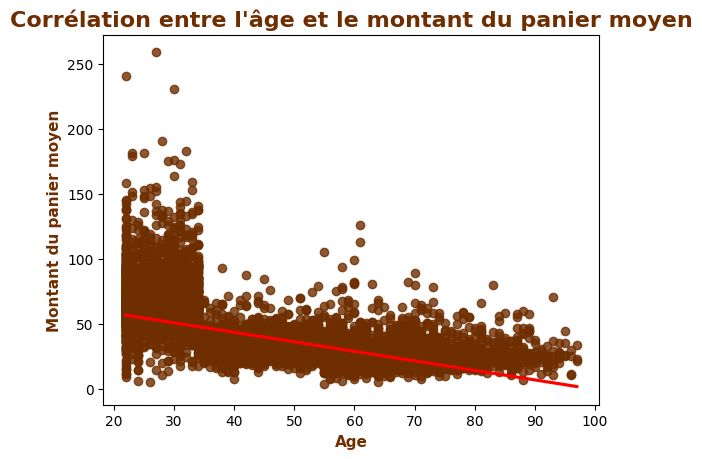

In [104]:
#Test de Spearman

# Visualisation de la tendance
sns.regplot(data=df_average_basket_by_client, x="age", y="average_basket", robust=True, line_kws=dict(color="r"), color="#6F2E00")

# Calculer le coefficient de corrélation de Spearman et la valeur p
spearman_corr, spearman_p_value = spearmanr(df_average_basket_by_client["age"], df_average_basket_by_client["average_basket"])

plt.title("Corrélation entre l'âge et le montant du panier moyen", fontsize=16, color="#6F2E00", weight="bold")
plt.xlabel("Age", fontsize=11, color="#6F2E00", weight="bold")
plt.ylabel("Montant du panier moyen", fontsize=11, color="#6F2E00", weight="bold")

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

alpha = 0.05
if spearman_p_value > alpha:
    print("Il n'y a pas de correlation entre l'âge et le montant du panier moyen")
else:
    print("Il existe une correlation entre l'âge et le montant du panier moyen")

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
<b>L'âge est inversement correlé au montant du panier moyen</b>
</p>
</div>

<div style="border: 1px solid RGB(160,111,119);" >
<h3 style="margin: auto; padding: 20px; color: RGB(160,111,119); ">Etapes 9.5 - Recherche d'un lien entre l'âge des clients et la catégorie des livres achetés</h3>
</div>

<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
L'<b>âge</b> des clients est une variable <b>quantitatives</b> et la <b>catégorie</b> des livres achetés est une variable <b>qualitative</b> donc on calcule la variance pour savoir quel test appliquer
<br />
Hypothèse H0 : Les moyennes de chaque groupe sont égales
<br />
Hypothèse H1 : Les moyennes de chaque groupe ne sont pas égales
 </p>
</div>

In [105]:
#Calcul de variance de chaque catégorie
for category in df_detail_transactions_b2c["category"].unique():
    variance_age = statistics.variance(df_detail_transactions_b2c[df_detail_transactions_b2c["category"] == category]["age"])
    print("La variance de l'âge pour la catégorie {} est de {}".format(category, variance_age))

La variance de l'âge pour la catégorie 0 est de 132.61274274854966
La variance de l'âge pour la catégorie 1 est de 249.43471166501058
La variance de l'âge pour la catégorie 2 est de 98.00730417785505


In [106]:
print("H0 : l'âge des clients suit une distribution normale")
print("H1 : l'âge des clients ne suit pas une distribution normale")

# Effectuer le test de Shapiro-Wilk
stat, p_value = shapiro(df_detail_transactions_b2c["age"])

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("L'âge des clients suit une distribution normale (on ne rejette pas H0)")
else:
    print("L'âge des clients ne suit pas une distribution normale (on rejette H0)")

H0 : l'âge des clients suit une distribution normale
H1 : l'âge des clients ne suit pas une distribution normale
Statistique du test de Shapiro-Wilk : 0.9717353855825366
Valeur p : 3.5461434587862934e-110
L'âge des clients ne suit pas une distribution normale (on rejette H0)


c:\Users\ndiem\anaconda3\envs\JEDHA\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 632689.
  res = hypotest_fun_out(*samples, **kwds)


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
L'<b>âge</b> des clients est une variable <b>quantitatives</b> et la <b>catégorie</b> des livres achetés est une variable <b>qualitative</b>, l'âge ne suit pas une distribution normale, la catégorie contient plus de 2 groupes et les variances des catégories sont différentes donc le test de <b>Kruskal-Wallis</b> sera réalisé
 </p>
</div>

[]

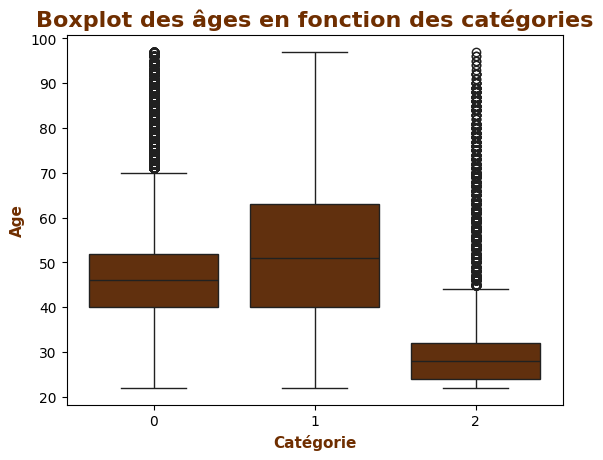

In [107]:
sns.boxplot(x="category", y="age", data=df_detail_transactions_b2c, color="#6F2E00")

plt.title("Boxplot des âges en fonction des catégories", fontsize=16, color="#6F2E00", weight="bold")
plt.xlabel("Catégorie", fontsize=11, color="#6F2E00", weight="bold")
plt.ylabel("Age", fontsize=11, color="#6F2E00", weight="bold")

plt.plot()

In [108]:
#Test de Kruskal-Wallis

print("H0 : Les moyennes de chaque groupe sont égales")
print("H1 : Les moyennes de chaque groupe ne sont pas égales")
kstat, pvalue = stats.kruskal(*[group["age"].values for name, group in df_detail_transactions_b2c[["category","age"]].groupby("category")])

print("Statistique H de Kruskal-Wallis", kstat)
print("Valeur pvalue", pvalue)

alpha = 0.05
if pvalue > alpha:
    print("Les moyennes de chaque groupe sont égales (on ne rejette pas H0)")
else:
    print("Les moyennes de chaque groupe ne sont pas égales (on rejette H0)")

H0 : Les moyennes de chaque groupe sont égales
H1 : Les moyennes de chaque groupe ne sont pas égales
Statistique H de Kruskal-Wallis 72214.83433330593
Valeur pvalue 0.0
Les moyennes de chaque groupe ne sont pas égales (on rejette H0)


<div>
<p style="margin: auto; padding: 20px; color: RGB(111,46,54);">
<b> L'âge a un impact sur les catégories de livre achetés. </b>
</p>
</div>